# 01. Logistic Regression and Classification Metrics

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the key concepts of this topic
- Apply the topic using Python code examples
- Practice with small, realistic datasets or scenarios

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — the binary cross-entropy loss you implemented by hand there is what `LogisticRegression` minimises.

**Used later in:** Course 07 (AIAT 121) — Unit 3, which classifies real text with this exact model, and Course 05 (AIAT 115) — Unit 4, lesson 05.

---


## 🌍 A real case: COMPAS and the argument that had no right answer

COMPAS is a risk score used in US courts to estimate whether a defendant will reoffend. On 23 May 2016
ProPublica published an audit of more than 7,000 defendants scored in Broward County, Florida in
2013–2014. Among defendants who did **not** go on to reoffend, **44.9% of Black defendants** had been
labelled higher risk, against **23.5% of white defendants**. Among those who **did** reoffend,
**47.7% of white defendants** had been labelled lower risk, against **28.0% of Black defendants**.
Overall the score was right about 61% of the time.

Northpointe, the vendor, replied that the score is equally **calibrated**: among people given the same
score, the reoffence rate is similar regardless of race. Both sides were correct about their own
numbers. Chouldechova (2017) and Kleinberg, Mullainathan & Raghavan (2016) then proved that when the
underlying rates differ between groups, **equal false-positive rates and equal predictive value cannot
both hold** — no threshold, no retraining, no better data makes the conflict go away.

**❗ Why this lesson exists.** This notebook reproduces that trade-off in miniature, on real card
transactions at their real fraud rate: **28 frauds in 16,000 transactions, 0.175%**. At the default
threshold the model gets precision 0.50 and recall 0.50 — of the 6 frauds in the test set it catches 3,
misses 3, and raises 3 false alarms. Switch on `class_weight='balanced'` and it catches the same 3
frauds while raising **18** false alarms instead of 3: recall unchanged at 0.50, precision down to 0.14.
**Nothing about the model changed. Only the price we put on the two kinds of error** — and this time
the price bought nothing. There is no setting that is "correct"; only a setting somebody chose, and
somebody else lives with.

⚠️ **And note the number you must not quote.** This model's *accuracy* is **99.81%**. Labelling every
single transaction "legitimate" scores **99.81%** too. Every honest statement in this notebook is made
with precision, recall and AUC.


# 01. Logistic Regression and Classification Metrics

---

## The Story: Predicting Categories Instead of Numbers

Imagine you're a fraud investigator. **Before** logistic regression, you can only predict continuous values (like transaction amounts). **After** logistic regression, you can predict categories (like "fraud" or "legitimate") - much more useful for threat detection!

Same with machine learning: **Before** logistic regression, we only predicted numbers (regression). **After** logistic regression, we can predict categories (classification) - opens up many new applications!

---

## Why Logistic Regression Matters

Logistic regression is the foundation of classification:
- **Simplest Classifier**: Easy to understand and interpret
- **Probability Outputs**: Gives probabilities, not just predictions
- **Fast and Efficient**: Works quickly on large datasets
- **Interpretable**: You can see how features affect class probability
- **Real-World Use**: Used in medicine, finance, marketing, and more

---

## 🌍 Real-World Applications

**Logistic Regression is used in MANY industries for binary classification problems!** Here's where you'll find it:

### 🏛️ Government & Public Safety Sector (GDI)
- **Fraud Detection**: Predict if financial transaction is fraudulent (fraud/legitimate) → terrorism financing detection
- **Threat Detection**: Predict if individual/activity poses security threat (threat/safe) → counter-espionage
- **Identity Verification**: Verify if person matches ID documents (match/no match) → border control
- **Suspicious Activity Detection**: Classify activities as suspicious/normal → surveillance systems
- **Crime Risk Assessment**: Predict if area/person has high crime risk (high risk/low risk) → crime prevention
- **Border Security**: Classify border crossings as legitimate/suspicious → immigration control

### 🔒 Security & Cybersecurity Sector
- **Intrusion Detection**: Predict if network activity is attack (attack/normal) → cyber threat detection
- **Malware Detection**: Classify software as malware or safe → cyber security
- **Access Control**: Predict if user access should be granted (grant/deny) → secure facilities
- **Anomaly Detection**: Classify behavior as normal or anomalous → security monitoring

### 💰 Finance & Banking Sector
- **Credit Approval**: Predict if loan applicant will default (approve/reject)
- **Fraud Detection**: Predict if transaction is fraudulent (fraud/legitimate)
- **Insurance Claims**: Predict if insurance claim is fraudulent (fraud/legitimate)
- **Customer Churn**: Predict if customer will leave bank (churn/stay)
- **Credit Card Approval**: Predict if credit card application should be approved
- **Risk Assessment**: Predict if investment is high risk (high risk/low risk)

### 📧 Email & Communication Sector
- **Spam Detection**: Classify emails as spam or not spam (most common use case!)
- **Sentiment Analysis**: Classify text as positive or negative sentiment
- **Language Detection**: Classify text as one language or another
- **Topic Classification**: Classify documents into categories (sports/news/tech)
- **Abuse Detection**: Detect abusive content in social media (abusive/normal)

### 📊 Marketing & E-commerce Sector
- **Customer Churn**: Predict if customer will stop buying (churn/retain)
- **Purchase Prediction**: Predict if customer will purchase product (buy/not buy)
- **Ad Click Prediction**: Predict if user will click ad (click/no click)
- **Customer Segmentation**: Classify customers into segments (high value/low value)
- **Product Recommendation**: Predict if customer will like product (like/dislike)
- **Price Sensitivity**: Predict if customer is price sensitive (sensitive/not sensitive)

### 🏭 Manufacturing & Quality Control
- **Defect Detection**: Predict if product is defective (defective/ok)
- **Quality Control**: Classify products as pass or fail quality inspection
- **Equipment Failure**: Predict if equipment will fail (fail/operational)
- **Maintenance Needs**: Predict if maintenance is needed (needed/not needed)
- **Production Issues**: Predict if production will have issues (issue/no issue)

### 🎓 Education Sector
- **Admission Prediction**: Predict if student will be admitted (admit/reject)
- **Student Success**: Predict if student will pass course (pass/fail)
- **Dropout Prediction**: Predict if student will drop out (dropout/continue)
- **Scholarship Eligibility**: Predict if student qualifies for scholarship
- **Course Recommendation**: Predict if student should take course

### 🔒 Security & Cybersecurity Sector
- **Intrusion Detection**: Predict if network activity is attack (attack/normal)
- **Malware Detection**: Classify software as malware or safe
- **Access Control**: Predict if user access should be granted (grant/deny)
- **Threat Detection**: Predict if system is under threat (threat/safe)
- **Anomaly Detection**: Classify behavior as normal or anomalous

### 🏥 Healthcare & Medical Sector
- **Disease Diagnosis**: Predict if patient has disease (cancer, diabetes, heart disease) based on symptoms, test results
- **Medical Imaging**: Classify medical images (X-rays, MRIs) as normal or abnormal
- **Drug Response**: Predict if patient will respond to treatment (respond/not respond)
- **Patient Readmission**: Predict if patient will be readmitted to hospital (yes/no)
- **Surgery Risk Assessment**: Predict if surgery will be successful (success/failure)
- **Disease Progression**: Predict if disease will progress (progress/stable)

### 💡 Why Logistic Regression is Popular:
- **Interpretable**: Easy to explain to non-technical stakeholders
- **Fast**: Quick to train and make predictions
- **Probability Outputs**: Gives probability scores (not just yes/no)
- **Baseline Model**: Often used as starting point for classification
- **Regulatory Compliance**: Some industries require interpretable models
- **Works Well**: Often performs well even compared to complex models

### 📈 When to Use Logistic Regression:
✅ **Use Logistic Regression when:**
- Need to predict binary categories (yes/no, pass/fail, spam/not spam)
- Need interpretable model (understandable by business stakeholders)
- Want probability outputs (not just predictions)
- Have linearly separable data (classes can be separated by a line)
- Need fast predictions on large datasets
- Want a baseline model before trying complex algorithms

❌ **Don't use Logistic Regression when:**
- Need to predict multiple categories (use multi-class classification)
- Data has complex non-linear boundaries (use SVM, Decision Trees)
- Need to capture complex feature interactions
- Have very imbalanced data (though can use class weights)
- Need highest possible accuracy (try ensemble methods)

---

## Learning Objectives
1. Build logistic regression models for binary classification
2. Understand classification metrics (accuracy, precision, recall, F1)
3. Interpret confusion matrices
4. Create and interpret ROC curves
5. Visualize decision boundaries
6. Know when logistic regression is appropriate

---

## 📋 Notebook Structure

**This notebook follows a logical learning progression:**

1. **Step 1**: Load Data - Load binary classification dataset (30 features, 16,000 rows at the real 0.175% fraud rate)
2. **Step 2**: Prepare Data - Extract features and target
3. **Step 3**: Split and Scale Data - Prepare for training
4. **Step 4**: Train Model - Build logistic regression model
5. **Sigmoid Visualization** - Understand how logistic regression converts linear to probabilities
6. **Step 5**: Evaluate Metrics - Calculate accuracy, precision, recall, F1
7. **Step 6**: Threshold Tuning - Explore different classification thresholds
8. **Step 7**: Handle Class Imbalance - Use class weights for imbalanced data
9. **Step 8**: Confusion Matrix - Visualize prediction errors
10. **Step 9**: ROC Curve - Evaluate model's ability to separate classes
11. **Step 10**: Decision Boundary - Visualize how model separates classes
12. **Step 11**: Decision Framework - When to use logistic regression
13. **Understanding Limitations** (Optional): When logistic regression doesn't work - using a synthetic non-linear example for demonstration

**Why this order?**
- **Foundation First**: Load and prepare data before modeling
- **Build Then Evaluate**: Train model, then evaluate it
- **Basic to Advanced**: Start with basic metrics, then advanced techniques
- **Visualization Last**: See results after understanding concepts
- **Limitations at End**: Understand when NOT to use it

**This structure ensures you understand each concept before moving to the next!**


In [1]:
# Step 1: Import necessary libraries
# These libraries help us build and evaluate classification models
# ALL imports are here at the beginning - this is best practice!

# Data manipulation and numerical operations
import pandas as pd               # For data manipulation
import numpy as np                # For numerical operations

# Visualization libraries
import matplotlib.pyplot as plt   # For visualizations
import seaborn as sns             # For beautiful plots

# Standard library utilities
from io import StringIO           # For capturing print output (used in classification report)
import sys                        # For system operations (used in classification report)

# Scikit-learn: Data loading
from sklearn.datasets import make_circles  # Generate non-linear data for the limitations example

# Scikit-learn: Data preprocessing
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.preprocessing import StandardScaler      # For scaling features

# Scikit-learn: Models
from sklearn.linear_model import LogisticRegression   # The classification model!

# Scikit-learn: Metrics
from sklearn.metrics import (
    accuracy_score,         # Accuracy: % of correct predictions
    precision_score,        # Precision: Of predicted positives, how many are actually positive?
    recall_score,           # Recall: Of actual positives, how many did we catch?
    f1_score,               # F1: Harmonic mean of precision and recall
    confusion_matrix,       # Shows true/false positives/negatives
    classification_report,  # Comprehensive classification metrics
    roc_curve,              # ROC curve (True Positive Rate vs False Positive Rate)
    roc_auc_score           # AUC: Area under ROC curve (0-1, higher is better)
)

print("✅ Libraries imported successfully!")
print("\n📚 What each classification metric does:")
print(" - Accuracy: Overall correctness")
print(" - Precision: How reliable are positive predictions?")
print(" - Recall: How many positives did we catch?")
print(" - F1: Balance between precision and recall")
print(" - ROC/AUC: How well model separates classes")

✅ Libraries imported successfully!

📚 What each classification metric does:
 - Accuracy: Overall correctness
 - Precision: How reliable are positive predictions?
 - Recall: How many positives did we catch?
 - F1: Balance between precision and recall
 - ROC/AUC: How well model separates classes


In [2]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root, put it on sys.path, then import the shared data loader.
# WHY:  a hard-coded relative path such as ../../datasets/raw/<file>.csv only resolves when
#       the kernel's working directory happens to be this notebook's folder. Open it from the
#       repository root, from JupyterLab at another level, or on Colab where there is no
#       repository at all, and it breaks. load() finds the data wherever you are, downloads
#       it if this machine has none, and says out loud which copy it used.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud", prefer="sample"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - no file paths needed, and this works on Colab too.")

Data loader ready - no file paths needed, and this works on Colab too.


## Part 1: Setting the Scene

**BEFORE**: We've been doing regression (predicting numbers like prices). Now we need classification (predicting categories like "fraud" or "legitimate").

**AFTER**: We'll build logistic regression - a classification model that predicts probabilities and categories!

**Why this matters**: Many real-world problems are classification (spam/not spam, fraud/not fraud, threat/safe). Logistic regression is the foundation!

---

## Step 1: Load Real-World Binary Classification Data

**BEFORE**: We need to learn classification, but we need real binary classification data (two classes: 0 and 1).

**AFTER**: We'll load a real-world financial dataset for terrorism financing detection with 30 features!

**Why this dataset?** This is a **REAL financial transactions dataset** from actual credit card transactions (anonymized), perfect for learning binary classification because it has:
- **Binary Classification**: 2 classes (Class 0 = Legitimate, Class 1 = Fraud/Terrorism Financing) - simplest classification problem
- **30 Numerical Features**: All features are continuous numbers (Time, V1-V28, Amount) - no encoding needed
- **Large Real-World Dataset**: the full file holds 284,807 REAL transactions; the 16,000-row extract that ships with this repository is what we read, drawn to keep the same fraud rate
- **Real-World Data**: **Actual financial transaction data** - not synthetic, shows real-world characteristics
- **Class Imbalance**: Highly imbalanced (99.83% legitimate, 0.17% fraud) - realistic for fraud detection!
- **GDI Relevance**: Aligned with Counter-Espionage and Terrorism Financing Detection - **this is what investigators actually use!**
- **Untouched Imbalance**: we do NOT re-balance the extract - the 0.175% fraud rate IS the lesson, and Steps 6 and 7 exist to show what to do about it

**For CS Students - Focus on Data Structure, Not Domain:**
- **Data Shape**: 16,000 rows × 30 columns (features) + 1 target column
- **Feature Type**: All numerical (continuous values like Time, Amount, and anonymized features V1-V28)
- **Target Type**: Binary (0 or 1) - categorical classification
- **Task**: Predict class 0 (Legitimate) or class 1 (Fraud/Terrorism Financing) based on 30 numerical features
- **Class Distribution**: Highly imbalanced (important for learning class imbalance handling)

---

### 📋 Understanding the Dataset Domain

**Important for CS Students**: You'll work with datasets from many different domains (financial, security, e-commerce, etc.). Understanding what the data represents helps you:
- **Understand the problem**: What are we trying to predict and why?
- **Interpret results**: What does "Class 0" vs "Class 1" mean in this context?
- **Choose appropriate metrics**: What matters more - precision or recall?
- **Communicate with domain experts**: You need to understand their terminology

**This Dataset: Credit Card Fraud / Terrorism Financing Detection**
- **Domain**: Financial Investigations / Counter-Espionage
- **GDI Theme**: Terrorism Financing Detection
- **What it measures**: Financial transaction characteristics
- **Features**: 30 numerical measurements (Time, Amount, and 28 anonymized features V1-V28 from PCA transformation)
- **Target**: Binary classification of transaction type

**Understanding the Classes:**
- **Class 0 (Legitimate)**: Normal, legitimate financial transaction
- **Class 1 (Fraud/Terrorism Financing)**: Suspicious transaction, potentially related to terrorism financing

**How to Detect Fraud/Terrorism Financing?**
- **Financial investigators** use features like:
  - **Time**: Transaction timing patterns (fraudulent transactions may have unusual timing)
  - **Amount**: Transaction amounts (terrorism financing may involve specific amounts)
  - **V1-V28**: Anonymized features from PCA transformation (capturing transaction patterns)
  - **Patterns**: Unusual transaction patterns, velocity, frequency, etc.

- **Our ML model** learns patterns from these 30 features to predict:
  - If features suggest legitimate transaction → Predict Class 0 (Legitimate)
  - If features suggest fraud/terrorism financing → Predict Class 1 (Fraud/Terrorism Financing)

**Why This Matters for Your Projects:**
- **Different domains = Different terminology**: Financial (fraud/legitimate), Security (threat/safe), Fraud Detection (fraud/legitimate)
- **Understanding the domain** helps you:
  - Choose the right evaluation metrics (e.g., in fraud detection: catching fraud is critical, but false alarms cost money)
  - Interpret model predictions correctly
  - Communicate results to stakeholders
  - Understand when the model makes sense vs when it doesn't

**For This Notebook**: Focus on the ML techniques, but remember - in real projects, you'll need to understand what your data represents!

---

**What makes this dataset good for learning?**
- **Clear Structure**: Features (X) and target (y) are clearly separated
- **No Preprocessing Needed**: All features are already numerical
- **Binary Target**: Only 2 classes - easiest classification problem
- **Good for Visualization**: Can visualize decision boundaries with 2 features
- **Real-World Imbalance**: Highly imbalanced dataset (realistic for fraud detection!)
- **Class Imbalance Handling**: Teaches `class_weight='balanced'` for handling imbalanced data
- **Practical Relevance**: Shows real GDI investigation scenario - detecting terrorism financing
- **Honest Resolution**: 28 real frauds in 16,000 rows means about 6 in the test split, so every fraud metric below moves in sixths - the notebook says so out loud rather than quoting three decimals

**💡 Important Note About What You Are Reading:**
- The full dataset has 284,807 transactions and 492 fraud cases (0.173%)
- This notebook reads the **16,000-row extract that ships with the repository**, drawn so the fraud
  RATE is preserved: **28 frauds, 0.175%** — the loader prints that line before anything else
- We deliberately do NOT re-balance it. Delete the imbalance and you delete the thing this lesson
  studies: what a 0.175% positive rate does to accuracy, precision, recall and the threshold
- The price is resolution, not honesty: about **6 frauds land in the test split**, so recall can only
  take values that are multiples of 1/6. Download the full file
  (`Course 04/datasets/DATA.md`) when you need three-decimal precision
- **This is REAL data** — every row is an untouched line from the original file

In [3]:
# Load Credit Card Fraud dataset (GDI Theme: Terrorism Financing Detection)
# This is a real-world financial dataset for binary classification
# Domain: Financial Investigations / Counter-Espionage - Terrorism Financing Detection
# Binary classification = predicting one of two classes (0 or 1)
# The full dataset has 30 numerical features (Time, V1-V28, Amount) and 284,807 samples
# We read the 16,000-row extract that ships in this repository - at the REAL fraud rate

print("\n📥 Loading Credit Card Fraud dataset...")
print(" GDI Theme: Terrorism Financing Detection")
print(" (Binary classification: Class 0 = Legitimate, Class 1 = Fraud/Terrorism Financing)")

try:
    # WHY load(...) and not a file path: it finds the data from ANY working directory - your
    # laptop, JupyterLab opened at the repository root, or Colab where there is no repository.
    # WHY prefer="sample": the 16,000-row extract ships inside the repository, drawn so the
    # fraud RATE matches the full file, so everyone in the class sees the numbers printed below.
    df_full = load('creditcard_fraud', prefer='sample')

    # We keep the extract EXACTLY as it comes: 16,000 rows at the real fraud rate.
    # WHY not re-balance it by throwing legitimate rows away? Because the imbalance IS the
    # lesson. Every experiment in this notebook - the threshold sweep in Step 6, the
    # class_weight comparison in Step 7, the whole argument that accuracy is the wrong
    # metric - is an experiment about what a 0.175% positive rate does to a classifier.
    # Delete the imbalance and you delete the thing you came here to study.
    df = df_full.sample(frac=1, random_state=73).reset_index(drop=True)   # shuffle only

    print(f"\n✅ Credit Card Fraud dataset loaded!")
    print(f" 📊 Rows read: {len(df_full):,} samples (REAL financial transaction data)")
    print(f" 📊 Working set: {len(df):,} samples - the extract, unaltered")
    print(f" - Legitimate: {(df['Class']==0).sum():,} ({(df['Class']==0).mean()*100:.1f}%)")
    print(f" - Fraud: {(df['Class']==1).sum():,} ({(df['Class']==1).mean()*100:.1f}%)")

    print(f"\n💡 Why we do NOT re-balance this data:")
    print(f" - The real rate is 0.17% fraud, and that is what you get here")
    print(f" - Predicting 'legitimate' for every single row would already score "
          f"{(df['Class'] == 0).mean():.4f} accuracy")
    print(f" - That number is the warning label for every metric printed below")
    print(f" - Steps 6 and 7 exist precisely to show what to do about it")
    print(f"\n⚠️  Know the resolution of your own experiment:")
    print(f" - This working set holds {(df['Class'] == 1).sum()} real frauds in total")
    print(f" - A 20% test split therefore holds about "
          f"{round((df['Class'] == 1).sum() * 0.2)} of them")
    print(f" - So recall can only land on multiples of 1/"
          f"{round((df['Class'] == 1).sum() * 0.2)}. Every fraud number below is honest,")
    print(f"   and none of it is precise to three decimals. Download the full 284,807-row")
    print(f"   file (Course 04/datasets/DATA.md) when you need precision.")

    print(f"\n📈 Features: All numerical (30 features: Time, V1-V28, Amount)")
    print(f" - Time: Transaction timestamp")
    print(f" - Amount: Transaction amount")
    print(f" - V1-V28: Anonymized features from PCA (capturing transaction patterns)")

    print(f"\n🎯 Target: Binary classification")
    print(f" - Class 0 = Legitimate transaction")
    print(f" - Class 1 = Fraud/Terrorism Financing (suspicious transaction)")

    print(f"\n🔍 For CS Students - Focus on Structure:")
    print(f" - Data shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f" - Feature type: All numerical (no encoding needed)")
    print(f" - Target type: Binary (0 or 1) - categorical classification")
    print(f" - Task: Predict class based on {len(df.columns)-1} features")
    print(f" - Class distribution: {(df['Class']==1).mean():.3%} fraud - the real rate, not a tidied-up one")

    print(f"\n🌍 Real-World GDI Context:")
    print(f" - Domain: Financial Investigations / Counter-Espionage")
    print(f" - Application: Terrorism financing detection through transaction analysis")
    print(f" - Real Data: Actual credit card transactions (anonymized for privacy)")
    print(f" - Practical: This is what GDI investigators use - detecting suspicious patterns!")
    print(f" - Perfect for learning binary classification with real-world relevance!")

except Exception as e:
    print(f"\n❌ Error loading dataset: {e}")
    raise


📥 Loading Credit Card Fraud dataset...
 GDI Theme: Terrorism Financing Detection
 (Binary classification: Class 0 = Legitimate, Class 1 = Fraud/Terrorism Financing)
creditcard_fraud: bundled 16,000-row sample of the 284,807-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified so the fraud rate stays 0.175% (28 fraud rows) against 0.173% in the full file; V1-V28 and Amount rounded to 6 decimals.

✅ Credit Card Fraud dataset loaded!
 📊 Rows read: 16,000 samples (REAL financial transaction data)
 📊 Working set: 16,000 samples - the extract, unaltered
 - Legitimate: 15,972 (99.8%)
 - Fraud: 28 (0.2%)

💡 Why we do NOT re-balance this data:
 - The real rate is 0.17% fraud, and that is what you get here
 - Predicting 'legitimate' for every single row would already score 0.9982 accuracy
 - That number is the warning label for every metric printed below
 - Steps 6 and 7 

## Step 2: Prepare Data for Modeling

**BEFORE**: We have the dataset loaded, but we need to extract features (X) and target (y) for modeling.

**AFTER**: We'll extract features and target, then prepare them for training!

**Why this step?** Models need features (X) and target (y) as separate arrays. We'll create both 2D features (for visualization) and all features (for modeling)!

**For CS Students:**
- **Features (X)**: Input variables (30 numerical features)
- **Target (y)**: Output variable (binary: 0 or 1)
- **X_2d**: 2 features for 2D visualization (easier to see decision boundaries)
- **X_all**: All 30 features for actual modeling (better performance)

In [4]:
# Prepare features (X) and target (y) from the loaded data
# We create two feature sets:
# - X_2d: 2 features for 2D visualization (easier to see decision boundaries)
# - X_all: All 30 features for actual modeling (better performance)

# Select 2 features for 2D visualization
feature_1_name = 'V1'  # First feature for 2D visualization
feature_2_name = 'V2'  # Second feature for 2D visualization

# Get all feature columns (exclude 'Class' which is the target)
feature_cols = [col for col in df.columns if col != 'Class']

X_2d = df[[feature_1_name, feature_2_name]].values  # 2 features for visualization
X_all = df[feature_cols].values                     # All 30 features for modeling
y = df['Class'].values  # Target: Binary (0 = Legitimate, 1 = Fraud/Terrorism Financing)

print(f"\n✅ Data prepared for modeling:")
print(f" X_2d (for visualization): {X_2d.shape[1]} features ({feature_1_name}, {feature_2_name})")
print(f" X_all (for modeling): {X_all.shape[1]} features")
print(f" Target (y): {len(y)} samples")
print(f" Features: {', '.join(feature_cols[:5])}... and {len(feature_cols)-5} more")


✅ Data prepared for modeling:
 X_2d (for visualization): 2 features (V1, V2)
 X_all (for modeling): 30 features
 Target (y): 16000 samples
 Features: Time, V1, V2, V3, V4... and 25 more


In [5]:
# Data summary and exploration
# Show what we've prepared for modeling
print(f"\n📊 Data Summary:")
print(f" Shape: {df.shape} (rows × columns)")
print(f" Features: {len(feature_cols)} numerical features")
print(f" Target: Binary classification (Class 0 = Legitimate, Class 1 = Fraud/Terrorism Financing)")

print(f"\n📄 First 5 rows (showing first 5 features + target):")
print(df[feature_cols[:5] + ['Class']].head())  # Show first 5 features + target

print(f"\n📊 Class Distribution:")
print(df['Class'].value_counts())

legitimate_count = (df['Class'] == 0).sum()
fraud_count = (df['Class'] == 1).sum()
print(f" - Class 0 (Legitimate): {legitimate_count} samples ({legitimate_count/len(df):.1%})")
print(f" - Class 1 (Fraud/Terrorism Financing): {fraud_count} samples ({fraud_count/len(df):.1%})")

print("\n🔍 For CS Students - Key Observations:")
print(" - All features are numerical (continuous values)")
print(" - Binary target: 2 classes (0 = Legitimate, 1 = Fraud/Terrorism Financing)")
if fraud_count / len(df) < 0.1:
    print(f" - ⚠️ Imbalanced: ~{legitimate_count/len(df):.1%} Legitimate, ~{fraud_count/len(df):.1%} Fraud")
    print(" - We'll handle this with class_weight='balanced' later in this notebook (Step 7)")
else:
    print(f" - Class distribution: ~{legitimate_count/len(df):.1%} Legitimate, ~{fraud_count/len(df):.1%} Fraud")
print(" - Domain context: Legitimate = normal transaction, Fraud = suspicious/terrorism financing")
print(" - GDI Context: Detecting terrorism financing through financial transaction patterns")
print(" - Perfect dataset for learning binary classification!")


📊 Data Summary:
 Shape: (16000, 31) (rows × columns)
 Features: 30 numerical features
 Target: Binary classification (Class 0 = Legitimate, Class 1 = Fraud/Terrorism Financing)

📄 First 5 rows (showing first 5 features + target):
       Time        V1        V2        V3        V4  Class
0  155055.0  2.007277  0.039685 -1.851307  0.353570      0
1   79470.0 -0.453873  0.118594  1.952676  1.277851      0
2   64633.0  1.411588 -1.072420  0.108497 -2.373833      0
3   63407.0 -0.626692  0.743761  2.036678  0.013749      0
4   48029.0  0.646865  1.764700 -1.977256  1.489382      0

📊 Class Distribution:
Class
0    15972
1       28
Name: count, dtype: int64
 - Class 0 (Legitimate): 15972 samples (99.8%)
 - Class 1 (Fraud/Terrorism Financing): 28 samples (0.2%)

🔍 For CS Students - Key Observations:
 - All features are numerical (continuous values)
 - Binary target: 2 classes (0 = Legitimate, 1 = Fraud/Terrorism Financing)
 - ⚠️ Imbalanced: ~99.8% Legitimate, ~0.2% Fraud
 - We'll handle thi

## Step 3: Split and Scale Data

**BEFORE**: We have features (X) and target (y), but we need to prepare them for training.

**AFTER**: We'll split data into train/test sets and scale features for optimal model performance!

**Why this step?**
- **Train/Test Split**: We need separate data for training (model learns) and testing (model evaluation)
- **Feature Scaling**: Logistic regression works better with scaled features (all features on same scale)
- **Stratify**: Maintains class distribution in both train and test sets (important for classification)

**This is a critical preprocessing step** - without it, the model won't train properly!

In [6]:
# Split data into training and testing sets
# Use X_all (all 30 features) for training - better performance than just 2 features!
# X_2d is only for visualization - we use all features for the actual model

# train_test_split(X, y, test_size=0.2, random_state=73, stratify=y)
# - Splits data into training and testing sets
# - X: Features (input variables), y: Target (output variable)
# - test_size=0.2: 20% for testing, 80% for training
# - random_state: Seed for reproducibility (same split every time)
#   💡 Why a specific number? Any number works (42, 73, 2024, etc.) - it's just a seed!
#   💡 Purpose: Ensures you get the SAME train/test split every time you run the code
#   💡 Without it: Different split each time → different results → hard to compare changes
# - stratify=y: Maintains class distribution in train/test (important for classification)
# - Returns: X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=73, stratify=y
)

print("✅ Data split into training and testing sets:")
print(f" Training samples: {len(X_train)}")
print(f" Test samples: {len(X_test)}")
print(f" Fraud cases in test set: {(y_test == 1).sum()}")

✅ Data split into training and testing sets:
 Training samples: 12800
 Test samples: 3200
 Fraud cases in test set: 6


In [7]:
# Scale features using StandardScaler
# scaler.fit_transform(X_train):
# - Two operations in one: .fit() then .transform()
#   1. .fit(): Learns parameters from data (mean/std of each feature)
#   2. .transform(): Applies transformation using learned parameters
# - Use .fit_transform() on training data only
# - For test data, use only .transform() (don't refit - avoids data leakage!)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled with StandardScaler:")
print(" - Each feature now has mean ≈ 0 and std ≈ 1")
print(" - Fitted on training data only, then applied to test data (no data leakage)")

✅ Features scaled with StandardScaler:
 - Each feature now has mean ≈ 0 and std ≈ 1
 - Fitted on training data only, then applied to test data (no data leakage)


## Step 4: Train Logistic Regression Model

**BEFORE**: We have binary classification data, but no model to predict classes.

**AFTER**: We'll train logistic regression to predict probabilities and classes!

**Why logistic regression?**
- **Similar to linear regression**: But outputs probabilities (0-1) instead of continuous values
- **Sigmoid function**: Squashes output to [0,1] range (probabilities)
- **Interpretable**: Coefficients show how features affect class probability
- **Fast**: Works quickly even on large datasets

In [8]:
# CELL: Train the logistic regression classifier.
# WHY: it learns a PROBABILITY of fraud for each transaction, not just a
# hard yes/no - that probability powers the threshold analysis later.
print("\n" + "=" * 60)
print("1. Training Logistic Regression Model")
print("=" * 60)

# Create and train logistic regression model
# max_iter=1000: Allow more iterations for convergence
# random_state=73: For reproducibility (using 73 for consistency)
# Note: We train WITHOUT class weights first - Step 7 will show how
# class_weight='balanced' changes the results on this imbalanced data
logistic_model = LogisticRegression(random_state=73, max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

print(" ✅ Model trained successfully!")
print(" Logistic regression learned to predict class probabilities")


1. Training Logistic Regression Model
 ✅ Model trained successfully!
 Logistic regression learned to predict class probabilities


## Understanding the Sigmoid Function

**BEFORE**: We trained logistic regression, but what does it actually do?

**AFTER**: We'll visualize the sigmoid function to understand how logistic regression converts linear combinations into probabilities!

**What is the Sigmoid Function?**
- **Input**: Linear combination of features (can be any real number: -∞ to +∞)
- **Output**: Probability (always between 0 and 1)
- **Formula**: `σ(z) = 1 / (1 + e^(-z))` where `z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b`
- **Purpose**: Squashes any real number into the [0, 1] range (probabilities)

**Why is this important?**
- Logistic regression outputs probabilities, not just classes
- We can adjust the threshold (default 0.5) to control precision/recall
- Understanding sigmoid helps you understand how the model makes decisions

**For CS Students:**
- **Linear Regression**: Output = any real number (e.g., -5.2, 100.5, -0.3)
- **Logistic Regression**: Output = probability between 0 and 1 (e.g., 0.2, 0.7, 0.95)
- **Sigmoid**: The function that converts linear output → probability

---

### 🔧 Methods We'll Use in This Visualization

**Before we visualize, let's understand the methods we'll use:**

1. **`.predict_proba()`** - Returns probabilities for each class
   - **Input**: Features (X)
   - **Output**: Array of probabilities [P(Class 0), P(Class 1)]
   - **Example**: `[0.2, 0.8]` means 20% chance Class 0, 80% chance Class 1
   - **Why**: Shows model's confidence, not just the prediction

2. **`.decision_function()`** - Returns the linear combination (z) before sigmoid
   - **Input**: Features (X)
   - **Output**: Raw score (z) - can be any real number
   - **Example**: z = 2.5 → sigmoid(2.5) ≈ 0.92 → high probability of Class 1
   - **Why**: Shows the "raw" linear combination before it's converted to probability

**In the visualization:**
- We'll use `.decision_function()` to get z values (x-axis)
- We'll use `.predict_proba()` to get probabilities (y-axis)
- This shows how z (linear) maps to probability (sigmoid)

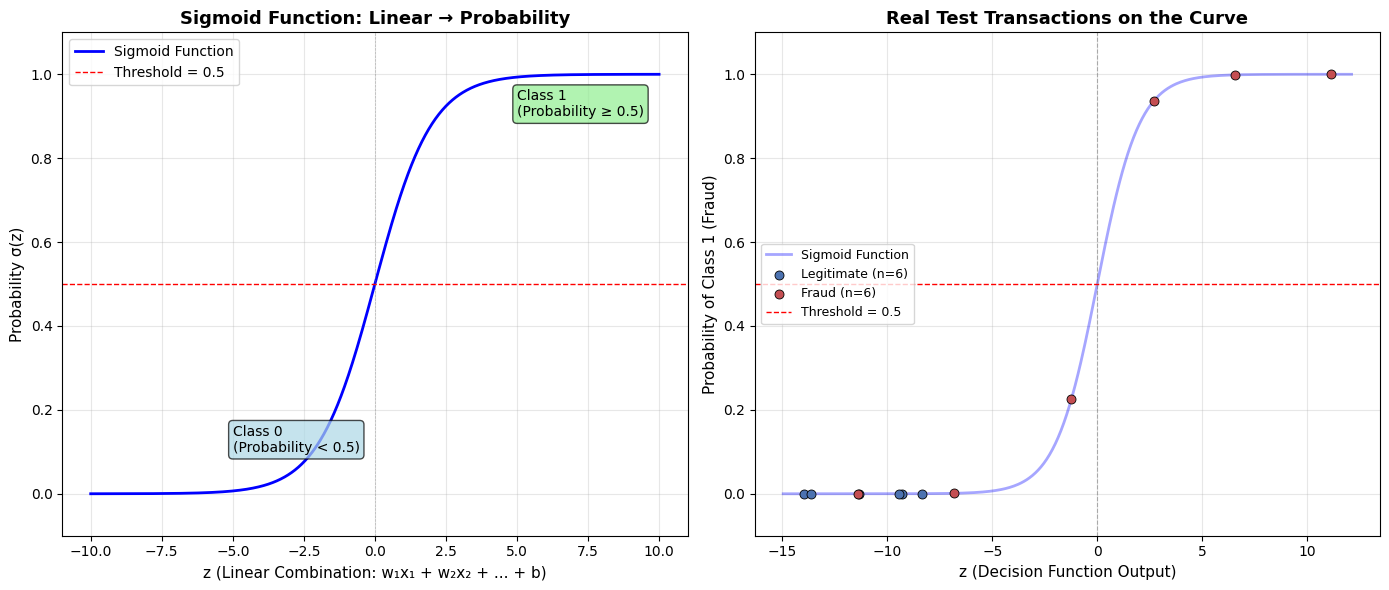


💡 Key Insights:
 - Left side (z < 0): Low probability → Predict Class 0
 - Right side (z > 0): High probability → Predict Class 1
 - At z = 0: Probability = 0.5 (decision boundary)
 - Sigmoid is S-shaped: Steepest change around z = 0
 - As z → +∞: Probability → 1 (very confident Class 1)
 - As z → -∞: Probability → 0 (very confident Class 0)

🔍 Notice (right-hand panel):
 - Red dots are the 6 real fraud cases; 3 of them sit ABOVE the 0.5 line
 - Blue dots are 6 legitimate transactions; 6 of them sit BELOW it
 - Every dot lies exactly ON the sigmoid: the model has one z per row, and
   the curve turns that z into the probability we threshold at 0.5
 - The two colours occupy opposite ends of the z axis - that separation IS the model


In [9]:
# Visualize the Sigmoid Function
# This shows how logistic regression converts linear combinations into probabilities
# Note: numpy and matplotlib are already imported in the imports cell

# Create range of z values (linear combination of features)
# z can be any real number (from very negative to very positive)
z = np.linspace(-10, 10, 1000)  # 1000 points from -10 to +10

# Calculate sigmoid function: σ(z) = 1 / (1 + e^(-z))
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(14, 6))

# Plot 1: Sigmoid curve
plt.subplot(1, 2, 1)
plt.plot(z, sigmoid, 'b-', linewidth=2, label='Sigmoid Function')
plt.axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Threshold = 0.5')
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.xlabel('z (Linear Combination: w₁x₁ + w₂x₂ + ... + b)', fontsize=11)
plt.ylabel('Probability σ(z)', fontsize=11)
plt.title('Sigmoid Function: Linear → Probability', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.ylim(-0.1, 1.1)
plt.annotate('Class 0\n(Probability < 0.5)', xy=(-5, 0.1), fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
plt.annotate('Class 1\n(Probability ≥ 0.5)', xy=(5, 0.9), fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Plot 2: where our REAL test transactions land on that same curve
plt.subplot(1, 2, 2)
# WHAT: take a STRATIFIED sample - every fraud case in the test set plus the
# same number of legitimate ones - and plot each one at (z, sigma(z)).
# WHY: sampling "the first 5 rows" would give five legitimate transactions,
# all bunched at P(fraud) ~ 0, and the right half of the picture would be
# empty - contradicting the claim that high z means "predict fraud".
y_test_arr = np.asarray(y_test)
fraud_idx = np.flatnonzero(y_test_arr == 1)          # positions of real fraud
legit_idx = np.flatnonzero(y_test_arr == 0)          # positions of legit rows
n_show = min(60, len(fraud_idx))                     # keep the plot readable
sample_idx = np.concatenate([fraud_idx[:n_show], legit_idx[:n_show]])

sample_z = logistic_model.decision_function(X_test_scaled[sample_idx])  # z
sample_p = logistic_model.predict_proba(X_test_scaled[sample_idx])[:, 1]  # sigma(z)
sample_y = y_test_arr[sample_idx]                    # the TRUE label of each dot

# Draw the sigmoid over whatever z-range the real data actually occupies.
z2 = np.linspace(min(-8, sample_z.min() - 1), max(8, sample_z.max() + 1), 400)
plt.plot(z2, 1 / (1 + np.exp(-z2)), 'b-', linewidth=2, alpha=0.35,
         label='Sigmoid Function')
plt.scatter(sample_z[sample_y == 0], sample_p[sample_y == 0], s=42,
            color='#4C72B0', edgecolors='black', linewidth=0.6, zorder=5,
            label=f'Legitimate (n={int((sample_y == 0).sum())})')
plt.scatter(sample_z[sample_y == 1], sample_p[sample_y == 1], s=42,
            color='#C44E52', edgecolors='black', linewidth=0.6, zorder=6,
            label=f'Fraud (n={int((sample_y == 1).sum())})')
plt.axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Threshold = 0.5')
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.xlabel('z (Decision Function Output)', fontsize=11)
plt.ylabel('Probability of Class 1 (Fraud)', fontsize=11)
plt.title('Real Test Transactions on the Curve', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9, loc='center left')
plt.ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

print("\n💡 Key Insights:")
print(" - Left side (z < 0): Low probability → Predict Class 0")
print(" - Right side (z > 0): High probability → Predict Class 1")
print(" - At z = 0: Probability = 0.5 (decision boundary)")
print(" - Sigmoid is S-shaped: Steepest change around z = 0")
print(" - As z → +∞: Probability → 1 (very confident Class 1)")
print(" - As z → -∞: Probability → 0 (very confident Class 0)")

print("\n🔍 Notice (right-hand panel):")
n_above = int((sample_p[sample_y == 1] >= 0.5).sum())
n_below = int((sample_p[sample_y == 0] < 0.5).sum())
print(f" - Red dots are the {int((sample_y == 1).sum())} real fraud cases; {n_above} of them sit ABOVE the 0.5 line")
print(f" - Blue dots are {int((sample_y == 0).sum())} legitimate transactions; {n_below} of them sit BELOW it")
print(" - Every dot lies exactly ON the sigmoid: the model has one z per row, and")
print("   the curve turns that z into the probability we threshold at 0.5")
print(" - The two colours occupy opposite ends of the z axis - that separation IS the model")


**Read the figure.** Left: the sigmoid itself — any real number `z` in, a probability between 0 and 1 out, crossing 0.5 exactly at `z = 0`. Right: our trained model's own test transactions dropped onto that curve. The blue dots (legitimate) sit at the low-`z` end near P(fraud) ≈ 0 and the red dots (fraud) sit at the high-`z` end above the dashed 0.5 line. Every dot lies *on* the curve because the sigmoid is the only thing standing between the linear score `z` and the probability. The red dots that fall *below* the line are the fraud cases this model will miss at the default threshold — the confusion matrix later in this notebook counts them.

In [10]:
# Make class predictions (0 or 1)
# .predict() returns the predicted class (0 or 1)
# Uses threshold of 0.5: if probability > 0.5, predict class 1, else class 0
y_train_pred = logistic_model.predict(X_train_scaled)
y_test_pred = logistic_model.predict(X_test_scaled)

print(f" ✅ Class predictions made!")
print(f" Training predictions: {len(y_train_pred)}")
print(f" Test predictions: {len(y_test_pred)}")

 ✅ Class predictions made!
 Training predictions: 12800
 Test predictions: 3200


In [11]:
# Get probability predictions (more informative than class predictions!)
# .predict_proba() returns probabilities for each class
# [:, 1] gets probability of class 1 (the positive class)
y_train_proba = logistic_model.predict_proba(X_train_scaled)[:, 1]
y_test_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("\n📊 Model Parameters:")
print(f" Coefficients: {logistic_model.coef_[0]}")
print(f" Intercept: {logistic_model.intercept_[0]:.4f}")
print(f"\n Interpretation:")
print(f" - Coefficients show how features affect class 1 probability")
print(f" - Positive coefficient → increases probability of class 1")
print(f" - Negative coefficient → decreases probability of class 1")


📊 Model Parameters:
 Coefficients: [-7.23369794e-02  6.48923234e-01 -5.47558398e-02 -2.75460589e-01
  1.60443518e+00 -3.06004613e-01 -9.28657942e-02 -4.39297665e-01
 -1.43886717e-01 -1.83803620e-01 -1.87880296e-01  4.75539512e-01
 -2.18275533e-01 -2.98848322e-01 -4.40224437e-01  5.73967187e-01
 -1.93377962e-01  3.07017991e-01  1.14426815e-01 -1.92660073e-01
  2.07341323e-01  5.52265086e-02  2.74378513e-01 -1.73040595e-01
  3.73472940e-01  7.16206436e-01  1.04366790e-01 -1.78220742e-01
 -2.64334539e-04  8.40498839e-02]
 Intercept: -10.4394

 Interpretation:
 - Coefficients show how features affect class 1 probability
 - Positive coefficient → increases probability of class 1
 - Negative coefficient → decreases probability of class 1


In [12]:
print("\n" + "=" * 60)
print("2. Evaluation Metrics")
print("=" * 60)


2. Evaluation Metrics


## Step 5: Classification Evaluation Metrics

**BEFORE**: We used MSE and R² for regression. Classification needs different metrics!

**AFTER**: We'll use classification metrics (accuracy, precision, recall, F1) that measure classification performance!

**Why different metrics?**
- **Regression**: Predicts numbers → use MSE, R²
- **Classification**: Predicts categories → use accuracy, precision, recall, F1
- **Each metric tells us something different**: Accuracy (overall), Precision (reliability), Recall (coverage), F1 (balance)

**⚠️ CRITICAL: When Are Metrics Calculated?

**Metrics are calculated AFTER training, on TEST data:**
1. **Step 1**: Train model on training data (model learns patterns)
2. **Step 2**: Model makes predictions on test data (unseen data)
3. **Step 3**: Calculate metrics by comparing predictions to actual labels
4. **Step 4**: Use metrics to evaluate model performance

**Why AFTER training?

### **The Purpose: Why We Calculate Metrics After Training**

**1. Metrics Measure Model Performance (Not Data Quality)**
- Metrics tell us: "How good is our trained model?"
- Before training: Model doesn't exist yet → nothing to measure!
- After training: Model learned patterns → we can test how well it learned

**2. We Need Predictions to Compare**
- Metrics = Comparison between predictions and actual values
- Before training: No predictions exist (model hasn't learned yet)
- After training: Model can make predictions → we can compare them to truth

**3. Test Data Shows Real-World Performance**
- Training metrics: Show if model memorized training data (may overfit)
- Test metrics: Show if model generalizes to NEW, unseen data (real performance)
- **Purpose**: We want to know how model performs on data it hasn't seen before!

**4. Metrics Guide Model Improvement**
- After training: We see metrics → identify problems → improve model
- Example: Low recall? → Model misses positives → adjust threshold or use class weights
- Before training: No metrics → no guidance → can't improve

**5. Metrics Validate the Model**
- After training: Metrics prove the model works (or doesn't)
- Before training: No validation possible → model might be useless

**Real-World Analogy:**
- 🎓 **Before training**: Like a student before studying (no knowledge to test)
- 📚 **Training**: Student learns from textbook (model learns from training data)
- 📝 **After training**: Student takes exam (model makes predictions on test data)
- ✅ **Metrics**: Exam score (how well student/model performs)

**What happens if you calculate metrics before training?**
- ❌ **Impossible!** You need a trained model to make predictions
- ❌ You can't calculate accuracy/precision/recall without predictions
- ❌ No model exists yet → nothing to evaluate
- ✅ **Always**: Train → Predict → Calculate Metrics

---

**🎯 The Purpose of Each Metric

### **When to Use Which Metric?**

| Metric | Purpose | When to Use | Example |
|--------|---------|-------------|---------|
| **Accuracy** | Overall correctness | Balanced classes, equal cost of errors | General classification |
| **Precision** | Reliability of positive predictions | False positives are costly | Spam detection (don't block real emails) |
| **Recall** | Coverage of actual positives | False negatives are costly | Fraud detection (catch all fraud cases) |
| **F1 Score** | Balance of precision and recall | Need both precision and recall | General use when classes are imbalanced |

### **Quick Reference: False Positives (FP) and False Negatives (FN)**

**Before we continue, let's understand these key terms:**

- **False Positive (FP)**: Model predicted Class 1, but actual is Class 0
  - **Example**: Model says "fraud" but transaction is legitimate (false alarm)
  - **Cost**: Blocking legitimate transactions, customer complaints
  
- **False Negative (FN)**: Model predicted Class 0, but actual is Class 1
  - **Example**: Model says "legitimate" but transaction is fraud (missed detection)
  - **Cost**: Missing the actual problem (very dangerous in fraud detection - allows fraud to go through!)

**💡 Note**: These will be explained in detail with examples in **Step 8: Confusion Matrix**. For now, just remember:
- **FP** = False alarm (predicted positive, but wrong)
- **FN** = Missed detection (predicted negative, but wrong)

---

### **Decision Tree: Which Metric to Focus On?**

```
Is missing a positive case (FN) worse than a false alarm (FP)?
├─ YES (FN worse) → Focus on RECALL
│   └─ Examples: Disease detection, fraud detection, security
│   └─ Goal: Catch ALL positive cases, even if some false alarms
│
├─ NO (FP worse) → Focus on PRECISION
│   └─ Examples: Spam detection, content moderation, recommendations
│   └─ Goal: Only predict positive when VERY sure
│
└─ BOTH matter equally → Use F1 SCORE
    └─ Examples: General classification, balanced problems
    └─ Goal: Balance between catching positives and being reliable
```

---

**Common Student Questions:**
- **Q: Why not just use accuracy?**
  - Answer: Accuracy can be misleading with imbalanced data!
  - Example: 99% negative, 1% positive → model predicts all negative = 99% accuracy (but useless!)
  - Solution: Use precision/recall to see performance on each class separately
- **Q: What's the difference between precision and recall?**
  - Answer: Precision = "Of what I predicted positive, how many were correct?"
  - Recall = "Of all actual positives, how many did I catch?"
  - Example: Medical test with high precision = few false alarms, high recall = catches most diseases
- **Q: Why F1 score? Why not just precision or recall?**
  - Answer: F1 balances precision and recall (harmonic mean)
  - Problem: High precision but low recall = misses many cases, high recall but low precision = many false alarms
  - Solution: F1 finds balance - good F1 = both precision and recall are decent
- **Q: When should I focus on precision vs recall?**
  - Answer: Depends on cost of errors:
  - High precision needed: Spam detection (few false positives = don't block real emails)
  - High recall needed: Disease detection (catch all diseases, even if some false alarms)
  - Balanced: Use F1 score
- **Q: Are metrics calculated before or after training?**
  - Answer: **AFTER training!** You must:
    1. Train the model first (model learns from data)
    2. Make predictions on test data
    3. Compare predictions to actual labels
    4. Calculate metrics from the comparison
  - You CANNOT calculate metrics before training because you need predictions first!

In [13]:
# Calculate all classification metrics at once
# This combines all metric calculations for better organization
#
# ⚠️ IMPORTANT: Metrics are calculated AFTER training!
#
# THE PURPOSE OF CALCULATING METRICS AFTER TRAINING:
# 1. We need a trained model first (model learned patterns from training data)
# 2. Model makes predictions on test data (unseen data)
# 3. We compare predictions to actual labels (ground truth)
# 4. Metrics tell us: "How well does the trained model perform?"
#
# WHY NOT BEFORE TRAINING?
# - No model exists yet → can't make predictions → can't calculate metrics
# - Metrics measure MODEL performance, not data quality
# - We need predictions to compare against actual values
#
# WHY TEST DATA (not training data)?
# - Training metrics: Show if model memorized (may overfit)
# - Test metrics: Show if model generalizes to NEW data (real-world performance)
# - Purpose: Validate that model works on unseen data, not just memorized patterns
#
# THE FLOW:
# Step 1: Model was trained (in previous cells) - model learned patterns
# Step 2: Model made predictions (y_train_pred, y_test_pred) - model applies what it learned
# Step 3: NOW we calculate metrics - compare predictions to truth
# Step 4: Metrics evaluate performance - guide model improvement

# Accuracy: Overall correctness (% of correct predictions)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Precision: Of predicted positives, how many are actually positive?
train_precision = precision_score(y_train, y_train_pred)
test_precision = precision_score(y_test, y_test_pred)

# Recall: Of actual positives, how many did we catch?
train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

# F1 Score: Harmonic mean of precision and recall (balances both)
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("✅ All classification metrics calculated!")
print(" Metrics computed for both training and test sets")

✅ All classification metrics calculated!
 Metrics computed for both training and test sets


In [14]:
# Display all calculated metrics
# Note: Metrics were calculated in the previous cell
print("\nTraining Metrics:")
print(f" Accuracy: {train_accuracy:.4f}")
print(f" Precision: {train_precision:.4f}")
print(f" Recall: {train_recall:.4f}")
print(f" F1 Score: {train_f1:.4f}")

print("\nTest Metrics:")
print(f" Accuracy: {test_accuracy:.4f}")
print(f" Precision: {test_precision:.4f}")
print(f" Recall: {test_recall:.4f}")
print(f" F1 Score: {test_f1:.4f}")

# Add interpretation
print("\n" + "=" * 60)
print("💡 Interpreting the Metrics")
print("=" * 60)

print(f"\n📊 Accuracy ({test_accuracy:.2%}):")
print(f" - The model correctly predicts {test_accuracy:.2%} of all cases")
print(f" - {'✅ Excellent!' if test_accuracy > 0.9 else '✅ Good!' if test_accuracy > 0.8 else '⚠️ Room for improvement'}")
print(f" - This is the overall correctness of the model")
_baseline_acc = float((np.asarray(y_test) == 0).mean())
print(f" - ⚠️ For scale: labelling EVERY row 'legitimate' already scores {_baseline_acc:.2%}.")
print(f"      This model is {test_accuracy - _baseline_acc:+.2%} against that do-nothing model.")
print(f"      Accuracy is not measuring the thing you care about here.")

print(f"\n📊 Precision ({test_precision:.2%}):")
print(f" - Of all cases predicted as Class 1, {test_precision:.2%} are actually Class 1")
print(f" - {'✅ High precision' if test_precision > 0.9 else '✅ Good precision' if test_precision > 0.8 else '⚠️ Low precision'}")
print(f" - High precision = few false positives (reliable positive predictions)")

print(f"\n📊 Recall ({test_recall:.2%}):")
print(f" - The model catches {test_recall:.2%} of all actual Class 1 cases")
print(f" - {'✅ High recall' if test_recall > 0.9 else '✅ Good recall' if test_recall > 0.8 else '⚠️ Low recall'}")
print(f" - High recall = few false negatives (catches most positives)")

print(f"\n📊 F1 Score ({test_f1:.2%}):")
print(f" - Harmonic mean of precision and recall: {test_f1:.2%}")
print(f" - {'✅ Excellent balance' if test_f1 > 0.9 else '✅ Good balance' if test_f1 > 0.8 else '⚠️ Imbalanced'}")
print(f" - Balances precision and recall (useful when classes are imbalanced)")

print(f"\n🔍 What to Notice:")
if test_precision > test_recall:
    print(f" - Precision ({test_precision:.2%}) > Recall ({test_recall:.2%})")
    print(f" - Model is CONSERVATIVE: careful about predicting Class 1")
    print(f" - Fewer false positives, but may miss some actual positives")
elif test_recall > test_precision:
    print(f" - Recall ({test_recall:.2%}) > Precision ({test_precision:.2%})")
    print(f" - Model is AGGRESSIVE: catches most positives")
    print(f" - Fewer false negatives, but may have more false positives")
else:
    _n_pos = int(np.asarray(y_test).sum())
    print(f" - Precision and Recall are equal ({test_precision:.2%})")
    print(f" - Read the LEVEL, not only the balance: of {_n_pos} real fraud cases in the test")
    print(f"   set the model caught {round(test_recall * _n_pos)} and missed "
          f"{_n_pos - round(test_recall * _n_pos)}, and raised the same number of false alarms.")

print(f"\n📚 What This Teaches Us:")
print(f" - Accuracy alone isn't enough - need precision and recall too")
print(f" - Precision vs Recall trade-off: can't maximize both simultaneously")
print(f" - F1 score helps balance this trade-off")
print(f" - Compare train vs test: train accuracy {train_accuracy:.2%} vs test {test_accuracy:.2%}")
if abs(train_accuracy - test_accuracy) > 0.05:
    print(f" - ⚠️ Large gap suggests possible overfitting!")
else:
    print(f" - ✅ Similar performance suggests good generalization")

print("\n" + "=" * 60)
print("🎯 Quick Reference: When to Use Which Metric?")
print("=" * 60)

print("\n📊 Use ACCURACY when:")
print(" - Classes are balanced (similar number of samples in each class)")
print(" - Cost of false positives = cost of false negatives")
print(" - You want overall performance measure")
print(" - Example: General classification problems")

print("\n📊 Use PRECISION when:")
print(" - False positives are COSTLY (worse than false negatives)")
print(" - You want reliable positive predictions")
print(" - Example: Spam detection (don't block real emails)")
print(" - Example: Content moderation (don't ban legitimate users)")

print("\n📊 Use RECALL when:")
print(" - False negatives are COSTLY (worse than false positives)")
print(" - You want to catch ALL positive cases")
print(" - Example: Fraud detection (don't miss any fraud cases)")
print(" - Example: Disease detection (catch all diseases)")

print("\n📊 Use F1 SCORE when:")
print(" - You need BOTH precision and recall")
print(" - Classes are imbalanced")
print(" - You want a balanced measure")
print(" - Example: General use when you need both metrics balanced")

print("\n💡 Remember:")
print(" - Metrics are calculated AFTER training (on test data)")
print(" - Choose metric based on your problem's cost of errors")
print(" - You can't maximize both precision and recall simultaneously")
print(" - F1 score balances the trade-off between precision and recall")

print("\n" + "=" * 60)
print("=" * 60)

print("\n📊 The Purpose: Metrics Guide Your Next Actions")
print(" Metrics are not just numbers - they tell you WHAT TO DO NEXT!")

print("\n🔄 The Improvement Cycle:")
print(" 1. Train model → Get metrics")
print(" 2. Analyze metrics → Identify problems")
print(" 3. Take action → Improve model")
print(" 4. Re-train → Get new metrics")
print(" 5. Repeat until satisfied!")
print("\n💡 This is REAL-WORLD practice used by Google, Amazon, Microsoft, and all ML companies!")
print(" This cycle is called 'Model Iteration' or 'MLOps' in industry")
print(" It's not just educational - it's how ML actually works in production!")

print("\n✅ Actions You Can Take Based on Metrics:")

print("\n1️⃣ If Accuracy is Low (< 70%):")
print(" - ✅ Check data quality (missing values, outliers)")
print(" - ✅ Add more features (collect more data)")
print(" - ✅ Try different algorithms (Decision Trees, SVM)")
print(" - ✅ Check if problem is non-linear (use non-linear models)")
print(" - ❌ Don't just edit dataset randomly - understand WHY it's low")

print("\n2️⃣ If Precision is Low (many false positives):")
print(" - ✅ Increase classification threshold (make model more conservative)")
print(" - ✅ Add features that help distinguish false positives")
print(" - ✅ Use class weights if classes are imbalanced")
print(" - ✅ Remove noisy features that cause false positives")

print("\n3️⃣ If Recall is Low (many false negatives):")
print(" - ✅ Decrease classification threshold (make model more aggressive)")
print(" - ✅ Use class_weight='balanced' for imbalanced classes")
print(" - ✅ Add features that help catch missed cases")
print(" - ✅ Collect more data for the minority class")

print("\n4️⃣ If Train Accuracy >> Test Accuracy (Overfitting):")
print(" - ✅ Add regularization (L1/L2)")
print(" - ✅ Reduce model complexity")
print(" - ✅ Get more training data")
print(" - ✅ Use cross-validation")

print("\n5️⃣ If Metrics are Good but Need Optimization:")
print(" - ✅ Tune hyperparameters (threshold, C parameter)")
print(" - ✅ Try feature engineering (create new features)")
print(" - ✅ Try ensemble methods (combine multiple models)")

print("\n📝 Can You Edit the Dataset?")
print(" ✅ YES, but carefully:")
print(" - Remove outliers (if they're errors)")
print(" - Handle missing values properly")
print(" - Add more data (especially for minority class)")
print(" - Create new features from existing ones")
print(" - ❌ DON'T remove data just because model predicts it wrong")
print(" - ❌ DON'T change labels to match predictions (that's cheating!)")

print("\n🎯 Real-World Workflow:")
print(" Step 1: Train model → Get metrics")
print(" Step 2: If metrics are poor → Identify the problem")
print(" Step 3: Take appropriate action (see above)")
print(" Step 4: Re-train with improvements")
print(" Step 5: Compare new metrics to old metrics")
print(" Step 6: If improved → Deploy! If not → Try different approach")

print("\n💡 Key Insight:")
print(" Metrics are your COMPASS - they point you toward improvement!")
print(" Low precision? → Focus on reducing false positives")
print(" Low recall? → Focus on catching more positives")
print(" Overfitting? → Focus on generalization")
print(" Good metrics? → You're ready to deploy!")

print("\n" + "=" * 60)
print("=" * 60)
print("\n✅ This workflow is used by:")
print(" - Google (Gmail spam detection, search ranking)")
print(" - Amazon (product recommendations, fraud detection)")
print(" - Netflix (movie recommendations)")
print(" - Banks (credit scoring, fraud detection)")
print(" - Hospitals (medical diagnosis systems)")
print(" - ALL machine learning companies!")
print("\n📚 Industry Terms:")
print(" - 'Model Iteration': The cycle of train → evaluate → improve")
print(" - 'MLOps': Machine Learning Operations (deploying and monitoring models)")
print(" - 'A/B Testing': Testing multiple models in production")
print(" - 'Model Versioning': Tracking different versions of models")
print("\n🎯 Bottom Line:")
print(" This is NOT just for learning - this is HOW ML works in the real world!")
print(" Every ML engineer, data scientist, and ML team follows this cycle!")


Training Metrics:
 Accuracy: 0.9996
 Precision: 1.0000
 Recall: 0.7727
 F1 Score: 0.8718

Test Metrics:
 Accuracy: 0.9981
 Precision: 0.5000
 Recall: 0.5000
 F1 Score: 0.5000

💡 Interpreting the Metrics

📊 Accuracy (99.81%):
 - The model correctly predicts 99.81% of all cases
 - ✅ Excellent!
 - This is the overall correctness of the model
 - ⚠️ For scale: labelling EVERY row 'legitimate' already scores 99.81%.
      This model is +0.00% against that do-nothing model.
      Accuracy is not measuring the thing you care about here.

📊 Precision (50.00%):
 - Of all cases predicted as Class 1, 50.00% are actually Class 1
 - ⚠️ Low precision
 - High precision = few false positives (reliable positive predictions)

📊 Recall (50.00%):
 - The model catches 50.00% of all actual Class 1 cases
 - ⚠️ Low recall
 - High recall = few false negatives (catches most positives)

📊 F1 Score (50.00%):
 - Harmonic mean of precision and recall: 50.00%
 - ⚠️ Imbalanced
 - Balances precision and recall (useful

## 🎯 What to Do AFTER Getting Metrics?

**BEFORE**: You've calculated metrics, but what's next? What do you DO with them?

**AFTER**: You'll understand how to use metrics to improve your model and make decisions!

**Why this matters**: Metrics are not just numbers - they're your **guide to improvement**! They tell you exactly what actions to take next.

---

### **The Purpose: Metrics Guide Your Actions**

**Metrics answer these critical questions:**
1. **Is my model good enough?** → If yes: Deploy! If no: Improve!
2. **What's wrong with my model?** → Low precision? Low recall? Overfitting?
3. **What should I do next?** → Adjust threshold? Add features? Change algorithm?

---

### **🔄 The Improvement Cycle**

```
1. Train Model → Get Metrics
2. Analyze Metrics → Identify Problem
3. Take Action → Improve Model
4. Re-train → Get New Metrics
5. Compare → Better? Deploy! Worse? Try Different Approach
6. Repeat until satisfied!
```

**This is iterative improvement** - you don't stop at the first metrics, you use them to get better!

---

### **✅ Is This Real-World Practice?

**YES! This is EXACTLY how machine learning works in industry!**

**This is NOT just educational** - this is the **standard workflow** used by:
- 🏢 **Tech Companies**: Google, Amazon, Microsoft, Meta
- 🏛️ **Government & Security**: Fraud detection and threat identification systems
- 💰 **Finance**: Fraud detection, credit scoring
- 🛒 **E-commerce**: Recommendation systems, spam detection
- 🚗 **Autonomous Vehicles**: Object detection, decision making

**Real-World Examples:**

**Example 1: Email Spam Detection (Gmail)**
1. Train model → Get metrics (85% accuracy, 90% precision, 80% recall)
2. Analyze: Low recall → Missing some spam emails
3. Action: Decrease threshold, add more spam features
4. Re-train → New metrics (87% accuracy, 88% precision, 85% recall)
5. Better! → Deploy to production
6. Monitor in production → If performance drops → Repeat cycle

**Example 2: Medical Diagnosis System**
1. Train model → Get metrics (92% accuracy, 95% precision, 88% recall)
2. Analyze: Low recall → Missing some diseases (CRITICAL!)
3. Action: Decrease threshold, use class weights, add more training data
4. Re-train → New metrics (91% accuracy, 93% precision, 94% recall)
5. Recall improved! → Deploy (better to catch all diseases)

**Example 3: Fraud Detection (Banking)**
1. Train model → Get metrics (95% accuracy, 70% precision, 90% recall)
2. Analyze: Low precision → Too many false alarms (blocking legitimate transactions)
3. Action: Increase threshold, add features to distinguish false positives
4. Re-train → New metrics (94% accuracy, 85% precision, 88% recall)
5. Precision improved! → Deploy (fewer false alarms)

**Industry Variations:**

**In Real Companies, They Also:**
- 📊 **A/B Testing**: Test multiple models in production
- 🔄 **Continuous Monitoring**: Track metrics over time
- 📈 **Model Versioning**: Keep track of which model version performs best
- 🎯 **Business Metrics**: Combine ML metrics with business KPIs
- 👥 **Team Collaboration**: Data scientists, engineers, product managers work together
- ⏱️ **Time Constraints**: Sometimes deploy "good enough" model, improve later

**But the Core Cycle is the Same:**
- Train → Evaluate → Improve → Re-train → Compare → Deploy/Monitor

**This is called "Model Iteration" or "MLOps" (Machine Learning Operations)** in industry!

**Key Point**: This cycle never ends! Even after deployment, you monitor metrics and continue improving!

---

### **✅ Actions Based on Metrics**

#### **If Accuracy is Low (< 70%):**
- ✅ **Check data quality**: Missing values, outliers, errors
- ✅ **Add more features**: Collect more relevant data
- ✅ **Try different algorithms**: Maybe logistic regression isn't right (try Decision Trees, SVM)
- ✅ **Check if problem is non-linear**: Use non-linear models if needed
- ❌ **Don't edit dataset randomly**: Understand WHY it's low first!

#### **If Precision is Low (Many False Positives):**
- ✅ **Increase threshold**: Make model more conservative (only predict positive when very sure)
- ✅ **Add distinguishing features**: Features that help separate false positives
- ✅ **Use class weights**: If classes are imbalanced
- ✅ **Remove noisy features**: Features that cause confusion

#### **If Recall is Low (Many False Negatives):**
- ✅ **Decrease threshold**: Make model more aggressive (catch more positives)
- ✅ **Use class_weight='balanced'**: For imbalanced classes
- ✅ **Add features**: Features that help catch missed cases
- ✅ **Collect more data**: Especially for minority class

#### **If Overfitting (Train >> Test Accuracy):**
- ✅ **Add regularization**: L1/L2 to prevent overfitting
- ✅ **Reduce complexity**: Simpler model
- ✅ **Get more training data**: More data = less overfitting
- ✅ **Use cross-validation**: Better evaluation

#### **If Metrics are Good:**
- ✅ **Tune hyperparameters**: Fine-tune for even better performance
- ✅ **Feature engineering**: Create new features
- ✅ **Try ensemble methods**: Combine multiple models
- ✅ **Deploy to production**: Your model is ready!

---

### **📝 Can You Edit the Dataset?**

**✅ YES, but carefully and for the right reasons:**

**✅ Good Reasons to Edit Dataset:**
- Remove outliers that are **errors** (not just because model predicts them wrong)
- Handle missing values **properly** (imputation, not deletion)
- Add more data (especially for minority class)
- Create new features from existing ones (feature engineering)
- Balance classes (if severe imbalance)

**❌ Bad Reasons (Cheating!):**
- Remove data because model predicts it wrong (that's the model's job to learn!)
- Change labels to match predictions (that's cheating!)
- Remove "hard" examples (model should learn to handle them)
- Only keep "easy" examples (model won't generalize)

**Key Principle**: Edit data to improve **data quality**, not to make metrics look better artificially!

---

### **🎯 Real-World Workflow Example**

**Scenario**: You trained a model and got 75% accuracy, 60% precision, 90% recall

**Step 1: Analyze Metrics**
- Accuracy: 75% (decent, but could be better)
- Precision: 60% (LOW - many false positives)
- Recall: 90% (HIGH - catches most positives)

**Step 2: Identify Problem**
- Model is too aggressive (high recall, low precision)
- Many false positives (predicts positive when it shouldn't)

**Step 3: Take Action**
- Increase threshold (from 0.5 to 0.7) → More conservative
- Add features that help distinguish false positives
- Re-train model

**Step 4: Get New Metrics**
- New accuracy: 80%
- New precision: 85% ✅ (improved!)
- New recall: 82% (slightly lower, but acceptable)

**Step 5: Decision**
- Metrics improved! → Deploy or continue optimizing
- If not improved → Try different approach (different algorithm, more data)

---

### **💡 Key Insights**

1. **Metrics are your compass** - they point you toward improvement
2. **Don't stop at first metrics** - use them to iterate and improve
3. **Each metric tells you different actions** - precision vs recall need different fixes
4. **Edit data wisely** - improve quality, don't cheat
5. **Iterative process** - train → evaluate → improve → repeat

**Remember**: The purpose of metrics is not just to see how good your model is, but to **guide you toward making it better**!

## Step 6: Exploring Classification Thresholds

**BEFORE**: We've been using the default threshold of 0.5 (if probability > 0.5, predict class 1).

**AFTER**: We'll explore how different thresholds affect precision and recall - this is crucial for real-world applications!

**Why this matters**: 
- **Default threshold (0.5)**: May not be optimal for your problem
- **Lower threshold (e.g., 0.3)**: More aggressive → Higher recall, lower precision
- **Higher threshold (e.g., 0.7)**: More conservative → Higher precision, lower recall
- **Real-world**: Fraud detection might need high recall (catch all fraud cases), spam detection might need high precision (don't block real emails)

**Common Student Questions:**
- **Q: Why not always use 0.5?**
  - Answer: 0.5 assumes equal cost of false positives and false negatives
  - Real-world: Missing fraud (FN) is worse than false alarm (FP) in fraud detection
  - Solution: Lower threshold for high recall, higher threshold for high precision
- **Q: How do I choose the right threshold?**
  - Answer: Depends on your problem's cost of errors
  - High recall needed: Fraud detection, threat detection (catch all cases)
  - High precision needed: Spam detection, content moderation (few false positives)
  - Balanced: Use F1 score to find optimal threshold

---

## 🎯 How to Decide Thresholds: A Complete Guide

**This is the most important question students ask!** Here's a step-by-step guide:

### **Method 1: Cost-Based Decision (Most Common)**

**Step 1: Identify the Cost of Errors**
- **False Positive (FP) Cost**: What happens if we predict positive but it's negative?
  - Example: Spam detection → Marking real email as spam → User misses important email
  - Example: Medical test → False alarm → Unnecessary stress, tests, costs
- **False Negative (FN) Cost**: What happens if we predict negative but it's positive?
  - Example: Fraud detection → Missing fraud → Fraudulent transaction goes through, financial loss
  - Example: Fraud detection → Missing fraud → Money lost

**Step 2: Compare Costs**
- **If FN cost >> FP cost** → Use **LOWER threshold** (0.3-0.4)
  - Priority: Catch all positives (high recall)
  - Examples: Fraud detection, threat detection, security monitoring
- **If FP cost >> FN cost** → Use **HIGHER threshold** (0.6-0.7)
  - Priority: Only predict positive when very sure (high precision)
  - Examples: Spam detection, content moderation, loan approval
- **If costs are similar** → Use **BALANCED threshold** (0.4-0.6)
  - Priority: Balance precision and recall
  - Examples: Customer churn, product recommendations

**Step 3: Test and Validate**
- Try different thresholds (0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8)
- Calculate precision, recall, F1 for each
- Choose threshold that minimizes your cost function

---

### **Method 2: Metric-Based Decision**

**For High Recall Problems** (Catch all positives):
- **Target**: Recall > 0.90 (catch 90%+ of positives)
- **Method**: Start with threshold = 0.3, increase until recall drops below target
- **Use when**: Missing positives is very costly
- **Examples**: 
  - Fraud detection: "Better to flag 100 transactions than miss 1 fraud case"
  - Fraud detection: "Better to flag 100 transactions than miss 1 fraud"

**For High Precision Problems** (Few false positives):
- **Target**: Precision > 0.90 (90%+ of predictions are correct)
- **Method**: Start with threshold = 0.7, decrease until precision drops below target
- **Use when**: False positives are very costly
- **Examples**:
  - Spam detection: "Better to miss some spam than block real emails"
  - Content moderation: "Better to miss some bad content than block good content"

**For Balanced Problems** (Balance both):
- **Target**: Maximize F1 score
- **Method**: Find threshold with highest F1 score
- **Use when**: Both precision and recall matter equally
- **Examples**:
  - Customer churn: "Balance between catching churners and not annoying loyal customers"
  - Product recommendations: "Balance between relevance and coverage"

---

### **Method 3: Business Rule-Based Decision**

**Step 1: Define Business Requirements**
- "We need to catch at least 95% of fraud cases" → Lower threshold
- "We can't have more than 5% false positives" → Higher threshold
- "We need both precision and recall above 80%" → Balanced threshold

**Step 2: Find Threshold That Meets Requirements**
- Test thresholds until you meet the requirement
- If impossible, you may need:
  - More training data
  - Better features
  - Different algorithm

---

### **Method 4: ROC Curve Analysis (Advanced)**

**Step 1: Plot ROC Curve**
- Shows True Positive Rate (TPR) vs False Positive Rate (FPR) for all thresholds
- Higher curve = better model

**Step 2: Choose Operating Point**
- **Top-left corner**: Best balance (high TPR, low FPR)
- **Left side**: High precision (fewer false positives)
- **Top side**: High recall (catch more positives)

**Step 3: Find Threshold at Operating Point**
- Use `roc_curve()` to get threshold for each point
- Choose threshold corresponding to your operating point

---

### **Quick Decision Framework

**Ask yourself these questions:**

1. **What's worse: Missing a positive (FN) or False alarm (FP)?**
   - Missing positive is worse → **Lower threshold (0.3-0.4)**
   - False alarm is worse → **Higher threshold (0.6-0.7)**
   - Both are similar → **Balanced threshold (0.4-0.6)**

2. **What's my minimum requirement?**
   - Need to catch 90%+ of positives → **Lower threshold**
   - Need 90%+ of predictions to be correct → **Higher threshold**
   - Need both → **Find threshold with best F1**

3. **What's my business constraint?**
   - Limited resources to handle positives → **Higher threshold** (fewer predictions)
   - Can't afford to miss positives → **Lower threshold** (catch everything)

---

### **Real-World Examples

| Problem | FN Cost | FP Cost | Recommended Threshold | Why |
|---------|---------|---------|----------------------|-----|
| **Fraud Detection** | Very High (miss fraud) | Low (false alarm) | **0.3-0.4** | Better to flag more than miss fraud |
| **Fraud Detection** | Very High (lose money) | Low (investigate) | **0.3-0.4** | Better to flag more than miss fraud |
| **Spam Detection** | Low (miss spam) | High (block real email) | **0.6-0.7** | Better to miss spam than block real emails |
| **Loan Approval** | Low (reject good loan) | High (approve bad loan) | **0.6-0.7** | Better to reject more than approve bad loans |
| **Customer Churn** | Medium | Medium | **0.4-0.6** | Balance between catching churners and not annoying customers |
| **Product Recommendation** | Medium | Medium | **0.4-0.6** | Balance between relevance and coverage |

---

### **Practical Steps to Find Your Threshold

**Step 1: Get Probabilities**
```python
y_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for class 1
```

**Step 2: Test Multiple Thresholds**
```python
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)
    # Calculate metrics
```

**Step 3: Evaluate Each Threshold**
- Calculate precision, recall, F1 for each threshold
- Plot precision/recall vs threshold (like we'll do below)
- Identify which threshold meets your requirements

**Step 4: Choose and Validate**
- Choose threshold based on your cost/requirements
- Validate on validation set (not test set!)
- Monitor in production and adjust if needed

---

### **Common Mistakes to Avoid

❌ **Mistake 1**: Always using 0.5
- **Why wrong**: Assumes equal cost of errors
- **Fix**: Choose threshold based on your problem

❌ **Mistake 2**: Optimizing on test set
- **Why wrong**: Overfitting to test set
- **Fix**: Use validation set for threshold selection

❌ **Mistake 3**: Ignoring business context
- **Why wrong**: Best metric might not be best for business
- **Fix**: Consider real-world costs and constraints

❌ **Mistake 4**: Not monitoring in production
- **Why wrong**: Data distribution changes over time
- **Fix**: Regularly re-evaluate and adjust threshold

---

---

## ⚠️ IMPORTANT: When Do We Use Thresholds?

**This is a common confusion point!** Let's clarify:

### **The Workflow

**Step 1: Train the Model FIRST** ✅
```python
# 1. Train the model (this happens ONCE)
model = LogisticRegression()
model.fit(X_train, y_train)  # Model learns from data
```

**Step 2: Get Probabilities** ✅
```python
# 2. Get probabilities from TRAINED model
y_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for class 1
# These probabilities are FIXED - they don't change!
```

**Step 3: Test Different Thresholds** ✅
```python
# 3. Test different thresholds (NO RETRAINING NEEDED!)
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_proba >= threshold).astype(int)  # Just change interpretation!
    # Calculate metrics for this threshold
```

**Step 4: Choose Optimal Threshold** ✅
```python
# 4. Choose the best threshold based on your needs
optimal_threshold = 0.4  # Example: best F1 score
```

**Step 5: Use Threshold for Predictions** ✅
```python
# 5. Use optimal threshold for future predictions
y_pred_final = (y_proba >= optimal_threshold).astype(int)
```

---

### **Key Points

✅ **Threshold selection happens AFTER training**
- You need the trained model to get probabilities
- You can't choose threshold before training (no probabilities yet!)

✅ **You DON'T retrain the model when changing threshold**
- The model outputs probabilities (e.g., 0.3, 0.7, 0.9)
- Threshold just changes how you interpret those probabilities
- Same probabilities → Different predictions based on threshold

✅ **The model is trained ONCE, threshold is applied MANY times**
- Train model: `model.fit()` (happens once)
- Get probabilities: `model.predict_proba()` (happens once)
- Apply threshold: `(y_proba >= threshold)` (can change anytime!)

---

### **Visual Example

**Imagine the model outputs these probabilities:**
```
Sample 1: 0.3 (30% chance of class 1)
Sample 2: 0.6 (60% chance of class 1)
Sample 3: 0.8 (80% chance of class 1)
```

**With threshold = 0.5:**
- Sample 1: 0.3 < 0.5 → Predict **Class 0**
- Sample 2: 0.6 ≥ 0.5 → Predict **Class 1**
- Sample 3: 0.8 ≥ 0.5 → Predict **Class 1**

**With threshold = 0.7 (higher):**
- Sample 1: 0.3 < 0.7 → Predict **Class 0**
- Sample 2: 0.6 < 0.7 → Predict **Class 0** (changed!)
- Sample 3: 0.8 ≥ 0.7 → Predict **Class 1**

**Notice:** Same probabilities, different predictions! No retraining needed!

---

### **Common Student Questions

**Q: Do I need to retrain the model when I change threshold?**
- **A: NO!** The model outputs probabilities. Threshold just changes how you interpret them.

**Q: When should I find the optimal threshold?**
- **A: AFTER training, on validation set** (not test set!)

**Q: Can I use different thresholds for different problems?**
- **A: YES!** Same trained model, different thresholds for different use cases.

**Q: What if I want to change threshold in production?**
- **A: Just change the threshold value!** No need to retrain the model.

---

### **The Complete Workflow

```
1. Split Data
   ├── Train Set (60%)
   ├── Validation Set (20%) ← Use for threshold selection
   └── Test Set (20%) ← Use for final evaluation

2. Train Model
   └── model.fit(X_train, y_train)

3. Get Probabilities on Validation Set
   └── y_val_proba = model.predict_proba(X_val)[:, 1]

4. Test Different Thresholds on Validation Set
   └── For each threshold: calculate metrics

5. Choose Optimal Threshold
   └── Based on your requirements (cost, F1, etc.)

6. Evaluate on Test Set (using optimal threshold)
   └── y_test_pred = (model.predict_proba(X_test)[:, 1] >= optimal_threshold)

7. Deploy Model with Optimal Threshold
   └── Use same threshold for all future predictions
```

---

**Now let's see this in action!** We'll test different thresholds and visualize the results.


Exploring Classification Thresholds

📊 Threshold Analysis:
Threshold    Accuracy     Precision    Recall       F1 Score    
------------------------------------------------------------
0.1          0.9975       0.4000       0.6667       0.5000      
0.2          0.9984       0.5714       0.6667       0.6154      
0.3          0.9981       0.5000       0.5000       0.5000      
0.4          0.9981       0.5000       0.5000       0.5000      
0.5          0.9981       0.5000       0.5000       0.5000      
0.6          0.9981       0.5000       0.5000       0.5000      
0.7          0.9981       0.5000       0.5000       0.5000      
0.8          0.9981       0.5000       0.5000       0.5000      
0.9          0.9981       0.5000       0.5000       0.5000      


📊 Optimal Threshold (by F1 Score): 0.2
 - This threshold balances precision and recall
 - F1 Score: 0.6154

🔍 Threshold Trade-offs:
 - Lower threshold (< 0.5): More aggressive → Higher recall, lower precision
 - Higher threshol

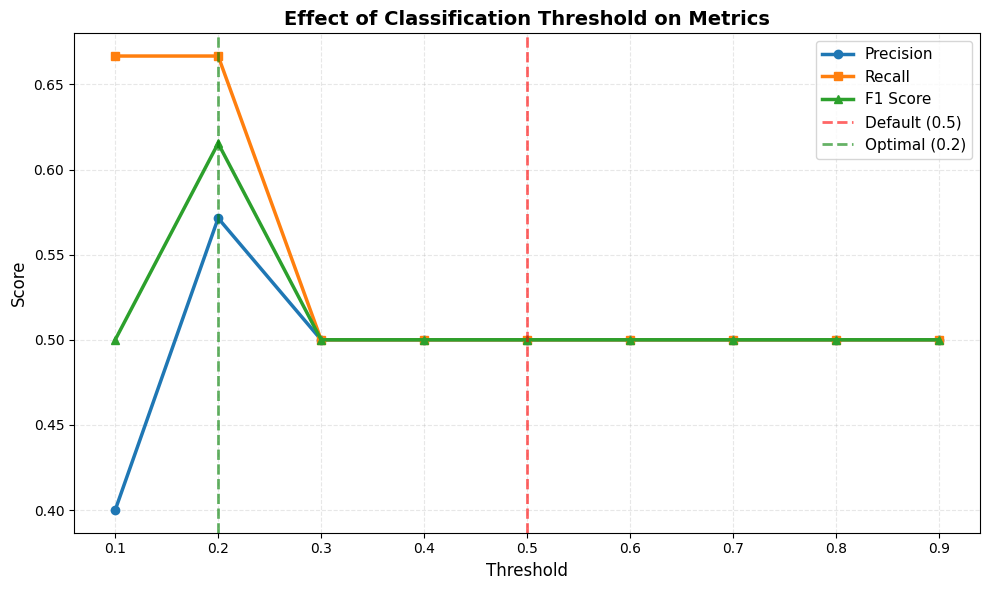



📊 Understanding the Threshold Plot:
 - Precision line (blue circles): Shows how precision changes with threshold
 - Recall line (orange squares): Shows how recall changes with threshold
 - F1 Score line (green triangles): Shows the balance between precision and recall
 - Red dashed line: Default threshold (0.5)
 - Green dashed line: Optimal threshold (best F1 score)

🔍 Key Observations:
 - As threshold INCREASES (moves right):
   → Precision INCREASES (fewer false positives)
   → Recall DECREASES (more false negatives)
 - As threshold DECREASES (moves left):
   → Precision DECREASES (more false positives)
   → Recall INCREASES (fewer false negatives)
 - The optimal threshold balances both (highest F1 score)

📚 What This Teaches Us:
 - Threshold selection is a critical hyperparameter!
 - You can't maximize both precision and recall simultaneously
 - Choose threshold based on your problem's cost of errors
 - Always explore different thresholds based on your problem's needs
 - Use proba

In [15]:
# Explore different classification thresholds
# The default threshold is 0.5, but we can adjust it based on our needs
# Lower threshold = more aggressive (higher recall, lower precision)
# Higher threshold = more conservative (higher precision, lower recall)

print("\n" + "=" * 60)
print("Exploring Classification Thresholds")
print("=" * 60)

thresholds = np.arange(0.1, 1.0, 0.1)
results = []

print("\n📊 Threshold Analysis:")
print(f"{'Threshold':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print("-" * 60)

for threshold in thresholds:
    y_pred_thresh = (y_test_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)

    results.append({
        'threshold': threshold,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    })

    print(f"{threshold:<12.1f} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

# Find optimal threshold (highest F1 score)
results_df = pd.DataFrame(results)
optimal_idx = results_df['f1'].idxmax()
optimal_threshold = results_df.loc[optimal_idx, 'threshold']

print("\n" + "=" * 60)
print("=" * 60)

print(f"\n📊 Optimal Threshold (by F1 Score): {optimal_threshold:.1f}")
print(f" - This threshold balances precision and recall")
print(f" - F1 Score: {results_df.loc[optimal_idx, 'f1']:.4f}")

print(f"\n🔍 Threshold Trade-offs:")
print(f" - Lower threshold (< 0.5): More aggressive → Higher recall, lower precision")
print(f" - Higher threshold (> 0.5): More conservative → Higher precision, lower recall")
print(f" - Default (0.5): Balanced approach (assumes equal cost of errors)")

print(f"\n📚 Real-World Applications:")
print(f" - Fraud detection: Use LOWER threshold (0.3-0.4) for high recall")
print(f"   → Don't miss fraud cases, even if some false alarms")
print(f" - Spam detection: Use HIGHER threshold (0.6-0.7) for high precision")
print(f"   → Don't block real emails, even if some spam gets through")
print(f" - Balanced: Use threshold with best F1 score (current: {optimal_threshold:.1f})")

plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], results_df['precision'], 'o-', label='Precision', linewidth=2.5, markersize=6)
plt.plot(results_df['threshold'], results_df['recall'], 's-', label='Recall', linewidth=2.5, markersize=6)
plt.plot(results_df['threshold'], results_df['f1'], '^-', label='F1 Score', linewidth=2.5, markersize=6)
plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.6, linewidth=2, label='Default (0.5)')
plt.axvline(x=optimal_threshold, color='g', linestyle='--', alpha=0.6, linewidth=2, label=f'Optimal ({optimal_threshold:.1f})')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Effect of Classification Threshold on Metrics', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("=" * 60)

print("\n📊 Understanding the Threshold Plot:")
print(" - Precision line (blue circles): Shows how precision changes with threshold")
print(" - Recall line (orange squares): Shows how recall changes with threshold")
print(" - F1 Score line (green triangles): Shows the balance between precision and recall")
print(" - Red dashed line: Default threshold (0.5)")
print(" - Green dashed line: Optimal threshold (best F1 score)")

print("\n🔍 Key Observations:")
print(" - As threshold INCREASES (moves right):")
print("   → Precision INCREASES (fewer false positives)")
print("   → Recall DECREASES (more false negatives)")
print(" - As threshold DECREASES (moves left):")
print("   → Precision DECREASES (more false positives)")
print("   → Recall INCREASES (fewer false negatives)")
print(" - The optimal threshold balances both (highest F1 score)")

print("\n📚 What This Teaches Us:")
print(" - Threshold selection is a critical hyperparameter!")
print(" - You can't maximize both precision and recall simultaneously")
print(" - Choose threshold based on your problem's cost of errors")
print(" - Always explore different thresholds based on your problem's needs")
print(" - Use probabilities (predict_proba) to adjust threshold, not just predictions")

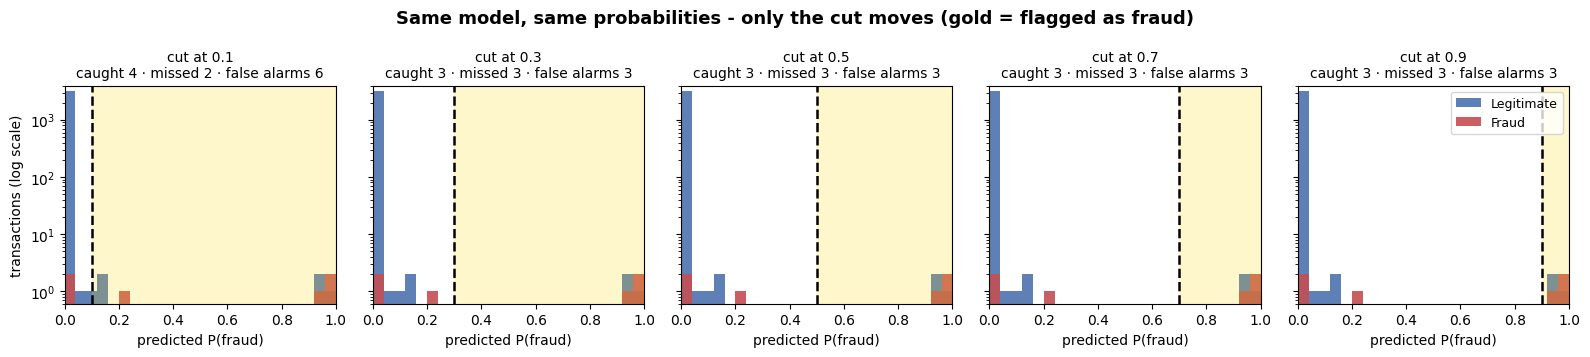


📊 Step table behind the storyboard (test set):
  cut  caught (TP)  missed (FN)  false alarms (FP)   recall  precision
----------------------------------------------------------------------
  0.1            4            2                  6    0.667      0.400
  0.3            3            3                  3    0.500      0.500
  0.5            3            3                  3    0.500      0.500
  0.7            3            3                  3    0.500      0.500
  0.9            3            3                  3    0.500      0.500


In [16]:
# CELL: Storyboard - the SAME probabilities, five different places to cut.
# WHY: the curves above summarise the sweep into three lines. Here is the raw
# material behind those lines: every test transaction placed on the probability
# axis. Nothing about the model changes between panels - only the black line.

frame_thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
y_test_arr = np.asarray(y_test)
p_legit = y_test_proba[y_test_arr == 0]   # predicted P(fraud) for legit rows
p_fraud = y_test_proba[y_test_arr == 1]   # predicted P(fraud) for real fraud
bins = np.linspace(0, 1, 26)

fig, axes = plt.subplots(1, len(frame_thresholds), figsize=(16, 3.6), sharey=True)
for ax, t in zip(axes, frame_thresholds):
    ax.hist(p_legit, bins=bins, color='#4C72B0', alpha=0.9, label='Legitimate')
    ax.hist(p_fraud, bins=bins, color='#C44E52', alpha=0.9, label='Fraud')
    ax.set_yscale('log')                       # class 0 outnumbers class 1 ~10:1
    ax.axvspan(t, 1.0, color='gold', alpha=0.20)   # shaded = flagged as fraud
    ax.axvline(t, color='black', linestyle='--', linewidth=1.8)
    flagged = y_test_proba >= t
    tp = int((flagged & (y_test_arr == 1)).sum())
    fp = int((flagged & (y_test_arr == 0)).sum())
    fn = int((~flagged & (y_test_arr == 1)).sum())
    ax.set_title(f"cut at {t:.1f}\ncaught {tp} · missed {fn} · false alarms {fp}",
                 fontsize=10)
    ax.set_xlabel('predicted P(fraud)', fontsize=10)
    ax.set_xlim(0, 1)
axes[0].set_ylabel('transactions (log scale)', fontsize=10)
axes[0].set_ylim(0.6, 4000)   # headroom so the legend never sits on a bar
axes[-1].legend(fontsize=9, loc='upper right')
fig.suptitle('Same model, same probabilities - only the cut moves '
             '(gold = flagged as fraud)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

print("\n📊 Step table behind the storyboard (test set):")
print(f"{'cut':>5} {'caught (TP)':>12} {'missed (FN)':>12} {'false alarms (FP)':>18} {'recall':>8} {'precision':>10}")
print("-" * 70)
for t in frame_thresholds:
    flagged = y_test_proba >= t
    tp = int((flagged & (y_test_arr == 1)).sum())
    fp = int((flagged & (y_test_arr == 0)).sum())
    fn = int((~flagged & (y_test_arr == 1)).sum())
    rec_t = tp / (tp + fn) if (tp + fn) else 0.0
    prec_t = tp / (tp + fp) if (tp + fp) else 0.0
    print(f"{t:>5.1f} {tp:>12d} {fn:>12d} {fp:>18d} {rec_t:>8.3f} {prec_t:>10.3f}")


**Read the storyboard.** Each panel is the *same* histogram of predicted fraud probabilities — blue for legitimate transactions, red for real fraud — and the only thing that changes from panel to panel is where the black dashed line sits. Everything in the gold band gets flagged as fraud. Read it left to right: as the cut slides right the gold band shrinks, so *caught* falls and *missed* rises, while *false alarms* falls. That is the precision–recall trade-off from the curve above, shown on the transactions themselves. Notice also how the two colours pile up at opposite ends of the axis: that gap is why any cut in the middle works reasonably well.

## Step 7: Handling Class Imbalance

**BEFORE**: We detected severe class imbalance (99.83% Class 0, 0.175% Class 1 — the real rate in
this data, not a tidied-up one), but didn't address it.

**AFTER**: We'll use `class_weight='balanced'` to automatically handle class imbalance!

**Why this matters**: 
- **Class imbalance**: One class has many more samples than the other
- **Problem**: Model may favor the majority class (predicts it more often)
- **Solution**: Use `class_weight='balanced'` to automatically weight classes inversely proportional to their frequency
- **Result**: Model pays more attention to minority class, improving recall for that class

**When to use class weights:**
- Class imbalance detected (one class > 60% of data)
- Minority class is important (e.g., fraud detection, threat detection)
- You want balanced precision/recall across classes

⚠️ **And be ready for it not to work.** `class_weight='balanced'` cannot conjure signal that is not
in the features. Watch what it actually does below before you assume it helps.

In [17]:
# Handle class imbalance using the class_weight parameter
# class_weight='balanced' automatically weights classes inversely proportional to frequency
# This helps the model pay more attention to the minority class

print("\n" + "=" * 60)
print("Handling Class Imbalance with class_weight")
print("=" * 60)

# First, let's check the class distribution to understand the imbalance
class_0_count = (y_test == 0).sum()
class_1_count = (y_test == 1).sum()
total = len(y_test)

print(f"\n📊 Class Distribution in Test Set:")
print(f" - Class 0: {class_0_count}/{total} ({class_0_count/total:.1%})")
print(f" - Class 1: {class_1_count}/{total} ({class_1_count/total:.1%})")
if abs(class_0_count - class_1_count) / total > 0.3:
    print(f" - ⚠️ Significant imbalance detected - class weights may help!")
else:
    print(f" - ✅ Imbalance is mild - but let's see if class weights improve performance")

print(f"\n💡 Why this matters:")
print(f" - Imbalanced classes can cause models to favor the majority class")
print(f" - class_weight='balanced' automatically adjusts for this imbalance")
print(f" - Let's compare models with and without class weights...")

# Train model with balanced class weights
# random_state: Any number works (42, 123, 2024, etc.) - just for reproducibility
logistic_balanced = LogisticRegression(
    random_state=123, max_iter=1000,
    class_weight='balanced'  # Automatically balance classes
)
logistic_balanced.fit(X_train_scaled, y_train)

y_train_pred_balanced = logistic_balanced.predict(X_train_scaled)
y_test_pred_balanced = logistic_balanced.predict(X_test_scaled)

# Calculate metrics for the balanced model
balanced_train_acc = accuracy_score(y_train, y_train_pred_balanced)
balanced_test_acc = accuracy_score(y_test, y_test_pred_balanced)
balanced_test_prec = precision_score(y_test, y_test_pred_balanced)
balanced_test_rec = recall_score(y_test, y_test_pred_balanced)
balanced_test_f1 = f1_score(y_test, y_test_pred_balanced)

# Compare with original model
print("\n📊 Comparison: Original vs Balanced Class Weights")
print("=" * 60)
print(f"\n{'Metric':<20} {'Original':<15} {'Balanced':<15} {'Difference':<15}")
print("-" * 65)
print(f"{'Test Accuracy':<20} {test_accuracy:<15.4f} {balanced_test_acc:<15.4f} {balanced_test_acc - test_accuracy:+.4f}")
print(f"{'Test Precision':<20} {test_precision:<15.4f} {balanced_test_prec:<15.4f} {balanced_test_prec - test_precision:+.4f}")
print(f"{'Test Recall':<20} {test_recall:<15.4f} {balanced_test_rec:<15.4f} {balanced_test_rec - test_recall:+.4f}")
print(f"{'Test F1 Score':<20} {test_f1:<15.4f} {balanced_test_f1:<15.4f} {balanced_test_f1 - test_f1:+.4f}")

# Per-class comparison
print("\n📊 Per-Class Performance Comparison:")
print("=" * 60)

# Get classification reports
# Note: StringIO and sys are already imported in the imports cell
old_stdout = sys.stdout
sys.stdout = report_capture = StringIO()
print(classification_report(y_test, y_test_pred, target_names=['Class 0', 'Class 1']))
original_report = report_capture.getvalue()
sys.stdout = old_stdout

sys.stdout = report_capture = StringIO()
print(classification_report(y_test, y_test_pred_balanced, target_names=['Class 0', 'Class 1']))
balanced_report = report_capture.getvalue()
sys.stdout = old_stdout

print("\nOriginal Model (no class weights):")
print(original_report)
print("\nBalanced Model (class_weight='balanced'):")
print(balanced_report)

print("\n" + "=" * 60)
print("=" * 60)

if abs(balanced_test_rec - test_recall) > 0.01:
    if balanced_test_rec > test_recall:
        print(f"\n✅ Class weights improved recall: {test_recall:.2%} → {balanced_test_rec:.2%}")
        print(f" - Model now catches more of the minority class (fraud)")
        print(f" - Trade-off: precision changed from {test_precision:.2%} to {balanced_test_prec:.2%}")
        print(f" - This is normal: class weights trade precision for recall")
    else:
        print(f"\n📊 Class weights changed recall: {test_recall:.2%} → {balanced_test_rec:.2%}")
        print(f" - Recall decreased slightly, but precision may have improved")
        print(f" - This is normal: class weights balance precision and recall")
        print(f" - Check if precision improved for the minority class")
else:
    print(f"\n📊 Class weights did NOT move recall: {test_recall:.2%} → {balanced_test_rec:.2%}")
    if abs(balanced_test_prec - test_precision) > 0.01:
        print(f" - But they moved precision a great deal: {test_precision:.2%} → "
              f"{balanced_test_prec:.2%}")
        print(f" - Read that carefully. Up-weighting the rare class pushed the model to flag more")
        print(f"   transactions; none of the extra flags turned out to be fraud, so recall stayed")
        print(f"   put while precision collapsed. class_weight is not a way to find fraud you were")
        print(f"   missing - it is a way to choose how many false alarms you will pay for.")
    else:
        print(f" - And they did not move precision either ({test_precision:.2%} → "
              f"{balanced_test_prec:.2%})")
        print(f" - On this split the weighting was not enough to change any decision")

print(f"\n🔍 When to Use class_weight='balanced':")
print(f" - Severe class imbalance (> 70/30 split)")
print(f" - Minority class is critical (fraud, threats, rare events)")
print(f" - You want balanced precision/recall across classes")
print(f" - Current dataset: {class_0_count}/{total} ({class_0_count/total:.1%}) vs {class_1_count}/{total} ({class_1_count/total:.1%})")
if abs(class_0_count - class_1_count) / total > 0.3:
    print(f" - ⚠️ Significant imbalance detected - class weights may help!")
    print(f" - 'May' is the operative word: the comparison above decides it, not the ratio")
else:
    print(f" - ✅ Imbalance is mild - original model is fine")

print(f"\n📚 What This Teaches Us:")
print(f" - class_weight='balanced' automatically handles class imbalance")
print(f" - It weights classes inversely proportional to frequency")
print(f" - Useful when minority class is important")
print(f" - May slightly reduce overall accuracy but improves minority class recall")
print(f" - Always compare with and without class weights!")


Handling Class Imbalance with class_weight

📊 Class Distribution in Test Set:
 - Class 0: 3194/3200 (99.8%)
 - Class 1: 6/3200 (0.2%)
 - ⚠️ Significant imbalance detected - class weights may help!

💡 Why this matters:
 - Imbalanced classes can cause models to favor the majority class
 - class_weight='balanced' automatically adjusts for this imbalance
 - Let's compare models with and without class weights...

📊 Comparison: Original vs Balanced Class Weights

Metric               Original        Balanced        Difference     
-----------------------------------------------------------------
Test Accuracy        0.9981          0.9934          -0.0047
Test Precision       0.5000          0.1429          -0.3571
Test Recall          0.5000          0.5000          +0.0000
Test F1 Score        0.5000          0.2222          -0.2778

📊 Per-Class Performance Comparison:

Original Model (no class weights):
              precision    recall  f1-score   support

     Class 0       1.00      1

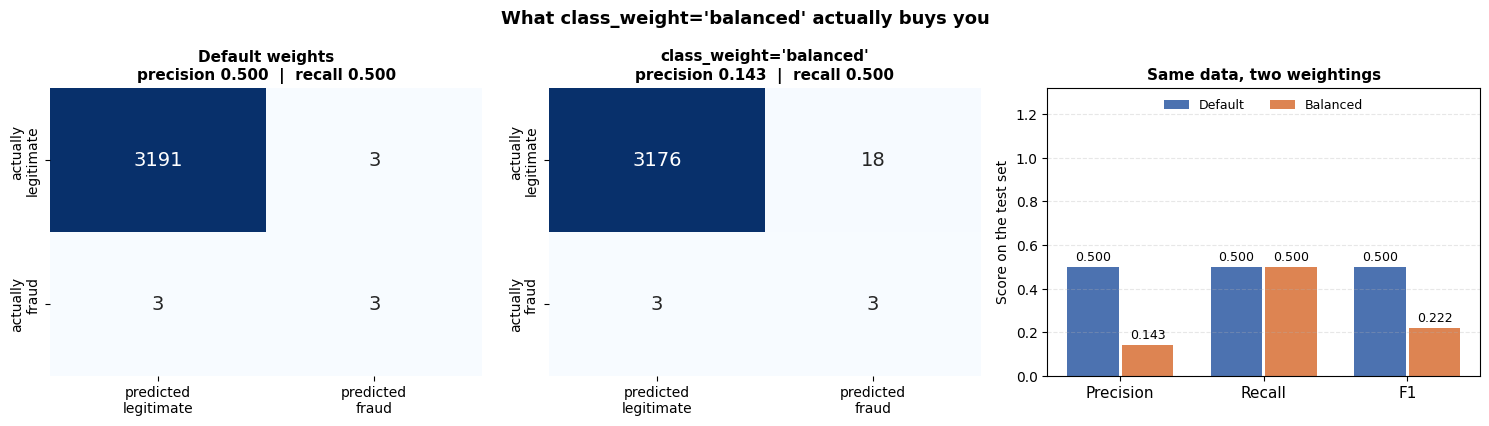


📊 Which predictions moved (test set):
 Fraud caught (TP):        3 -> 3   (+0)
 Fraud missed (FN):        3 -> 3   (+0)
 False alarms (FP):        3 -> 18   (+15)
 Legit cleared (TN):       3191 -> 3176   (-15)

💡 Class weights do not create information - they move the operating point.


In [18]:
# CELL: Draw the trade-off that the table above only tabulates.
# WHY: "recall went up, precision went down" is four numbers; the picture shows
# WHICH cells of the confusion matrix moved, which is what the trade-off IS.

cm_default = confusion_matrix(y_test, y_test_pred)           # model from Step 4
cm_balanced = confusion_matrix(y_test, y_test_pred_balanced)  # class_weight='balanced'

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
panels = [
    (cm_default, "Default weights", test_precision, test_recall),
    (cm_balanced, "class_weight='balanced'", balanced_test_prec, balanced_test_rec),
]
for ax, (cmx, name, prec_, rec_) in zip(axes[:2], panels):
    sns.heatmap(cmx, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                annot_kws={'size': 14},
                xticklabels=['predicted\nlegitimate', 'predicted\nfraud'],
                yticklabels=['actually\nlegitimate', 'actually\nfraud'])
    ax.set_title(f"{name}\nprecision {prec_:.3f}  |  recall {rec_:.3f}",
                 fontsize=11, fontweight='bold')

# Third panel: the same two models as bars, so the direction of each change is
# visible at a glance instead of being read out of two grids.
metric_names = ['Precision', 'Recall', 'F1']
default_vals = [test_precision, test_recall, test_f1]
balanced_vals = [balanced_test_prec, balanced_test_rec, balanced_test_f1]
xpos = np.arange(len(metric_names))
ax = axes[2]
b1 = ax.bar(xpos - 0.19, default_vals, width=0.36, color='#4C72B0', label='Default')
b2 = ax.bar(xpos + 0.19, balanced_vals, width=0.36, color='#DD8452', label='Balanced')
for bars in (b1, b2):
    ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=2)
ax.set_xticks(xpos)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.32)
ax.set_ylabel('Score on the test set')
ax.set_title('Same data, two weightings', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper center', ncol=2, frameon=False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('What class_weight=\'balanced\' actually buys you',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

# Print the exact cells that moved, so the caption can never drift from the data.
tn0, fp0, fn0, tp0 = cm_default.ravel()
tn1, fp1, fn1, tp1 = cm_balanced.ravel()
print("\n📊 Which predictions moved (test set):")
print(f" Fraud caught (TP):        {tp0} -> {tp1}   ({tp1 - tp0:+d})")
print(f" Fraud missed (FN):        {fn0} -> {fn1}   ({fn1 - fn0:+d})")
print(f" False alarms (FP):        {fp0} -> {fp1}   ({fp1 - fp0:+d})")
print(f" Legit cleared (TN):       {tn0} -> {tn1}   ({tn1 - tn0:+d})")
print("\n💡 Class weights do not create information - they move the operating point.")


**Read the figure.** The two grids are the same test set scored by the same features; only the weighting changed. Compare them cell by cell: the top-right cell (false alarms) jumps from **3 to 18** — balancing the classes pushed the model to say "fraud" six times as often. Now look at the bottom-right cell (fraud caught): **3 in both grids.** Fifteen extra transactions were flagged and not one of them was fraud.

**What it proves:** class weighting moves the *operating point*, it does not add information. Here the extra aggression bought zero additional frauds, so recall stayed at 0.50 while precision fell from 0.50 to 0.14. Read the printed "which predictions moved" table underneath for the exact counts — that is the trade-off you are being asked to price, and on this split it is a trade with nothing on one side of it.

In [19]:
# Classification Report for the main model
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred,
                            target_names=['Class 0', 'Class 1']))

# Add interpretation
print("\n" + "=" * 60)
print("💡 Reading the Classification Report")
print("=" * 60)

print("\n📊 Understanding Each Column:")
print(" - Precision: Of predictions for this class, how many were correct?")
print(" - Recall: Of actual cases of this class, how many did we catch?")
print(" - F1-score: Balance between precision and recall")
print(" - Support: Number of actual cases of this class in test set")

print("\n🔍 What to Look For:")
print(" - Compare Class 0 vs Class 1 metrics (check for class imbalance)")
print(" - High precision = reliable predictions for that class")
print(" - High recall = catches most cases of that class")
print(" - F1-score shows overall performance for each class")

print("\n📚 Key Insights:")
class_0_count = (y_test == 0).sum()
class_1_count = (y_test == 1).sum()
total = len(y_test)
print(f" - Class distribution: {class_0_count}/{total} ({(class_0_count/total):.1%}) Class 0, {class_1_count}/{total} ({(class_1_count/total):.1%}) Class 1")
if abs(class_0_count - class_1_count) / total > 0.2:
    print(f" - ⚠️ Class imbalance detected! This affects model performance")
    print(f" - Model may favor the majority class")
else:
    print(f" - ✅ Classes are relatively balanced")

print("\n💡 Learning Point:")
print(" - Classification report shows per-class performance")
print(" - Important when classes are imbalanced (one class has more samples)")
print(" - Accuracy can be misleading with imbalanced classes!")
print(" - Always check precision and recall for each class separately")


Classification Report (Test Set):
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00      3194
     Class 1       0.50      0.50      0.50         6

    accuracy                           1.00      3200
   macro avg       0.75      0.75      0.75      3200
weighted avg       1.00      1.00      1.00      3200


💡 Reading the Classification Report

📊 Understanding Each Column:
 - Precision: Of predictions for this class, how many were correct?
 - Recall: Of actual cases of this class, how many did we catch?
 - F1-score: Balance between precision and recall
 - Support: Number of actual cases of this class in test set

🔍 What to Look For:
 - Compare Class 0 vs Class 1 metrics (check for class imbalance)
 - High precision = reliable predictions for that class
 - High recall = catches most cases of that class
 - F1-score shows overall performance for each class

📚 Key Insights:
 - Class distribution: 3194/3200 (99.8%) Class 0, 6/3200 (0.2%) 

## 💬 Discuss

This is the argument this course was built for. Take a side and defend it with the numbers above.

1. **Which error costs more — and did weighting actually help?** `class_weight='balanced'` left recall
   at 50.0% (3 of the 6 test frauds, both times) and dropped precision from 50.0% to 14.3%: 3 false
   alarms became 18. Which model do you ship? Now answer again as the bank's fraud team, and again as
   the customer whose card is refused at a petrol station at 2 a.m. Did your answer change? Should it
   have? Then answer the sharper question: on *this* evidence, is there any cost ratio at all that
   makes the balanced model the right choice?

2. **F1 picked threshold 0.2, not 0.5** — but F1 weights precision and recall equally, and nobody
   ever decided that fraud works that way. Write down what one missed fraud costs and what one false
   alarm costs, in riyals. Whatever numbers you choose, defend them — then read off the threshold
   table which threshold *your* numbers select. Compare with the person next to you.

3. **Every fraud number here rests on 6 positive cases.** Recall can only be 0, 1/6, 2/6 … and one
   transaction changing sides moves it by 17 points. Which of the claims in this notebook survive that,
   and which are noise? Say what you would need — more rows, more frauds, repeated splits — before you
   would put any of these numbers in a report.

4. **Take this model to a Saudi bank.** Suppose it declines a higher share of transactions in one
   region than another. Is that discrimination, an accurate reflection of where fraud actually
   happens, or both at once? Given the COMPAS result — that you cannot equalise every fairness
   measure at the same time — which one would you choose to equalise, and what evidence would change
   your mind?

## Step 8: Confusion Matrix

**BEFORE**: We have metrics (accuracy, precision, recall), but we don't know WHERE errors occur.

**AFTER**: We'll visualize the confusion matrix to see exactly which predictions were wrong!

**Why this step?**
- **Confusion Matrix**: Shows WHERE errors occur (which class was misclassified)
- **Visual Understanding**: See false positives and false negatives clearly
- **Error Analysis**: Understand if model favors one class over another
- **Foundation**: Needed to understand precision, recall, and F1 score

### 📚 Understanding TP, FP, TN, FN

**Before we create the confusion matrix, let's understand the four types of predictions:**

For binary classification (Class 0 and Class 1), every prediction falls into one of four categories:

#### **1. True Positive (TP) ✅✅**
- **Predicted**: Class 1
- **Actual**: Class 1
- **Meaning**: Model correctly predicted the positive class
- **Example**: Patient has disease (Class 1), model predicts disease (Class 1) ✅
- **Result**: **Correct prediction** - Model got it right!

#### **2. True Negative (TN) ✅✅**
- **Predicted**: Class 0
- **Actual**: Class 0
- **Meaning**: Model correctly predicted the negative class
- **Example**: Patient is healthy (Class 0), model predicts healthy (Class 0) ✅
- **Result**: **Correct prediction** - Model got it right!

#### **3. False Positive (FP) ❌✅**
- **Predicted**: Class 1 (Positive)
- **Actual**: Class 0 (Negative)
- **Meaning**: Model incorrectly predicted positive when it should be negative
- **Example**: Transaction is legitimate (Class 0), but model predicts fraud (Class 1) ❌
- **Result**: **Type I Error** - False alarm! Model cried "wolf" when there was no wolf
- **Cost**: In fraud detection, this means blocking legitimate transactions, customer complaints
- **Also called**: False alarm, Type I error

#### **4. False Negative (FN) ✅❌**
- **Predicted**: Class 0 (Negative)
- **Actual**: Class 1 (Positive)
- **Meaning**: Model incorrectly predicted negative when it should be positive
- **Example**: Patient has disease (Class 1), but model predicts healthy (Class 0) ❌
- **Result**: **Type II Error** - Missed detection! Model missed the actual problem
- **Cost**: In medical diagnosis, this means missing a disease (very dangerous!)
- **Also called**: Missed detection, Type II error

---

### 🎯 Quick Memory Trick

**Think of it this way:**
- **True/False**: Was the prediction correct? (True = correct, False = wrong)
- **Positive/Negative**: What did the model predict? (Positive = Class 1, Negative = Class 0)

**Examples:**
- **True Positive**: Prediction was **True** (correct), and it predicted **Positive** (Class 1) ✅
- **False Positive**: Prediction was **False** (wrong), but it predicted **Positive** (Class 1) ❌
- **True Negative**: Prediction was **True** (correct), and it predicted **Negative** (Class 0) ✅
- **False Negative**: Prediction was **False** (wrong), but it predicted **Negative** (Class 0) ❌

---

### 📊 Confusion Matrix Layout

The confusion matrix is a 2×2 table showing all four categories:

```
                Predicted
              Class 0  Class 1
Actual  Class 0   TN     FP
        Class 1   FN     TP
```

**Reading the matrix:**
- **Rows** = Actual (true) class
- **Columns** = Predicted class
- **Diagonal** (TN and TP) = Correct predictions ✅
- **Off-diagonal** (FP and FN) = Incorrect predictions ❌

**For our medical example:**
- **TN**: Correctly predicted healthy (Class 0)
- **FP**: Incorrectly predicted disease when healthy (false alarm)
- **FN**: Incorrectly predicted healthy when disease (missed disease - dangerous!)
- **TP**: Correctly predicted disease (Class 1)

---

### 💡 Why This Matters

**Understanding TP, FP, TN, FN helps you:**
1. **See WHERE errors occur**: Are errors mostly FP or FN?
2. **Understand costs**: In fraud detection, FN (missing fraud) is worse than FP (false alarm)
3. **Calculate metrics**: Precision, Recall, and F1 all use these four numbers
4. **Improve the model**: If many FP → increase threshold, if many FN → decrease threshold

**Real-world example:**
- **Spam detection**: FP (blocking real email) is worse than FN (letting spam through)
- **Fraud detection**: FN (missing fraud) is worse than FP (false alarm)
- **Fraud detection**: FN (missing fraud) is worse than FP (flagging legitimate transaction)

In [20]:
# CELL: Build the confusion matrix - the four ways a prediction can be right or wrong.
# WHY: accuracy hides WHICH mistakes happen; here a false negative (missed fraud)
# costs far more than a false alarm.
print("\n" + "=" * 60)
print("3. Confusion Matrix")
print("=" * 60)

# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print("\n📊 Confusion Matrix:")
print(" Format: [TN FP]")
print("         [FN TP]")
print(cm)

print("\n💡 Understanding:")
print(" - TN (True Negative): Correctly predicted class 0")
print(" - FP (False Positive): Predicted 1, but actually 0 (Type I error)")
print(" - FN (False Negative): Predicted 0, but actually 1 (Type II error)")
print(" - TP (True Positive): Correctly predicted class 1")

# Extract values for interpretation
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
total = tn + fp + fn + tp

print("\n" + "=" * 60)
print("💡 Interpreting the Confusion Matrix")
print("=" * 60)

print(f"\n📊 Breakdown:")
print(f" - True Negatives (TN): {tn} - Correctly predicted Class 0")
print(f" - False Positives (FP): {fp} - Predicted Class 1, but actually Class 0")
print(f" - False Negatives (FN): {fn} - Predicted Class 0, but actually Class 1")
print(f" - True Positives (TP): {tp} - Correctly predicted Class 1")
print(f" - Total: {total} test samples")

print(f"\n🔍 Error Analysis:")
print(f" - Total errors: {fp + fn} out of {total} ({((fp + fn) / total):.1%})")
print(f" - False Positives: {fp} ({fp/total:.1%}) - Model predicted Class 1 when it should be Class 0")
print(f" - False Negatives: {fn} ({fn/total:.1%}) - Model predicted Class 0 when it should be Class 1")

if fp > fn:
    print(f" - ⚠️ More False Positives ({fp}) than False Negatives ({fn})")
    print(f" - Model is too aggressive in predicting Class 1")
elif fn > fp:
    print(f" - ⚠️ More False Negatives ({fn}) than False Positives ({fp})")
    print(f" - Model is too conservative, missing Class 1 cases")
else:
    print(f" - ✅ Balanced errors: {fp} FP and {fn} FN")

print(f"\n📚 What This Teaches Us:")
print(f" - Confusion matrix shows WHERE errors occur (which class)")
print(f" - Helps identify if model has bias toward one class")
print(f" - FP and FN have different costs in real-world applications")
print(f" - Example: In fraud detection, FN (missing fraud) is worse than FP (false alarm)")
print(f" - Can calculate precision, recall, and F1 from these numbers")


3. Confusion Matrix

📊 Confusion Matrix:
 Format: [TN FP]
         [FN TP]
[[3191    3]
 [   3    3]]

💡 Understanding:
 - TN (True Negative): Correctly predicted class 0
 - FP (False Positive): Predicted 1, but actually 0 (Type I error)
 - FN (False Negative): Predicted 0, but actually 1 (Type II error)
 - TP (True Positive): Correctly predicted class 1

💡 Interpreting the Confusion Matrix

📊 Breakdown:
 - True Negatives (TN): 3191 - Correctly predicted Class 0
 - False Positives (FP): 3 - Predicted Class 1, but actually Class 0
 - False Negatives (FN): 3 - Predicted Class 0, but actually Class 1
 - True Positives (TP): 3 - Correctly predicted Class 1
 - Total: 3200 test samples

🔍 Error Analysis:
 - Total errors: 6 out of 3200 (0.2%)
 - False Positives: 3 (0.1%) - Model predicted Class 1 when it should be Class 0
 - False Negatives: 3 (0.1%) - Model predicted Class 0 when it should be Class 1
 - ✅ Balanced errors: 3 FP and 3 FN

📚 What This Teaches Us:
 - Confusion matrix shows WHER

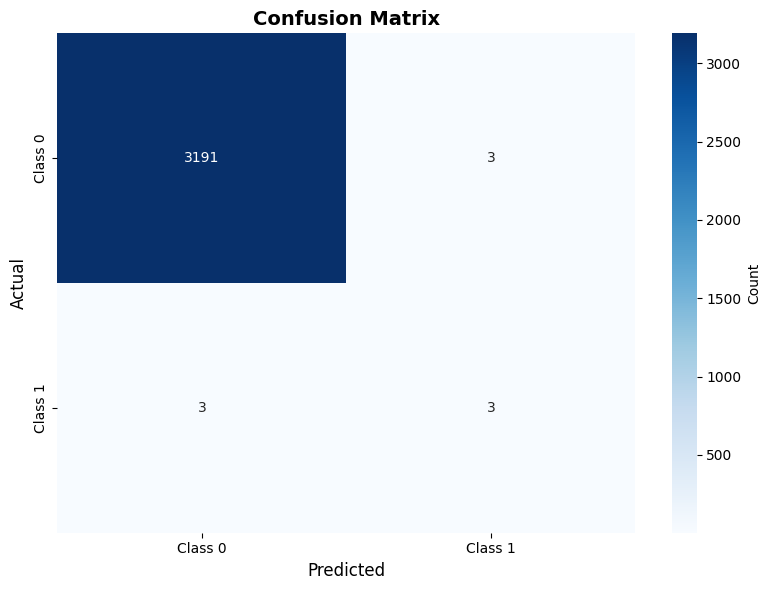


💡 What You Should See in This Plot:
 - A 2x2 heatmap with numbers in each cell
 - Darker blue = higher numbers (more predictions)
 - Top-left (TN): Correctly predicted Class 0
 - Top-right (FP): Incorrectly predicted Class 1 (should be Class 0)
 - Bottom-left (FN): Incorrectly predicted Class 0 (should be Class 1)
 - Bottom-right (TP): Correctly predicted Class 1
 - A good model has high numbers on the diagonal (TN and TP)
 - A poor model has high numbers off the diagonal (FP and FN)


In [21]:
# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'],
            cbar_kws={'label': 'Count'})  # Add colorbar label for clarity
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 What You Should See in This Plot:")
print(" - A 2x2 heatmap with numbers in each cell")
print(" - Darker blue = higher numbers (more predictions)")
print(" - Top-left (TN): Correctly predicted Class 0")
print(" - Top-right (FP): Incorrectly predicted Class 1 (should be Class 0)")
print(" - Bottom-left (FN): Incorrectly predicted Class 0 (should be Class 1)")
print(" - Bottom-right (TP): Correctly predicted Class 1")
print(" - A good model has high numbers on the diagonal (TN and TP)")
print(" - A poor model has high numbers off the diagonal (FP and FN)")

## Step 9: ROC Curve and AUC

**BEFORE**: We have accuracy, precision, recall, but we need a metric that works across all thresholds.

**AFTER**: We'll create an ROC curve and calculate AUC to evaluate model performance across all possible thresholds!

**Why this step?**
- **ROC Curve**: Shows model performance across ALL possible thresholds (not just 0.5)
- **AUC Score**: Single number that summarizes model's ability to separate classes
- **Threshold Independent**: Unlike accuracy, AUC doesn't depend on a fixed threshold
- **Industry Standard**: AUC is widely used in industry for model comparison

In [22]:
print("\n" + "=" * 60)
print("4. ROC Curve and AUC")
print("=" * 60)


4. ROC Curve and AUC


In [23]:
# Calculate ROC curve and AUC score
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

print(f"\nAUC Score: {auc_score:.4f}")

# Add interpretation
print("\n" + "=" * 60)
print("💡 Understanding AUC Score")
print("=" * 60)

print(f"\n📊 AUC (Area Under Curve) = {auc_score:.4f}")
print(f" - Range: 0.0 to 1.0")
print(f" - 0.5 = Random guessing (worst)")
print(f" - 1.0 = Perfect classifier (best)")
print(f" - Our score: {auc_score:.4f} ({auc_score*100:.1f}%)")

if auc_score >= 0.9:
    print(f" - ✅ EXCELLENT! (>0.9 means model can distinguish classes very well)")
elif auc_score >= 0.8:
    print(f" - ✅ GOOD! (>0.8 means model has good discriminative ability)")
elif auc_score >= 0.7:
    print(f" - ⚠️ FAIR (>0.7 means model has some ability, but room for improvement)")
elif auc_score >= 0.6:
    print(f" - ⚠️ POOR (>0.6 but <0.7 means model struggles to separate classes)")
else:
    print(f" - ❌ VERY POOR (<0.6 means model is barely better than random)")

print(f"\n🔍 What AUC Measures:")
print(f" - How well the model can distinguish between Class 0 and Class 1")
print(f" - Higher AUC = better at separating the two classes")
print(f" - AUC is independent of the classification threshold")
print(f" - Useful for comparing different models")

print(f"\n📚 What This Teaches Us:")
print(f" - AUC evaluates model performance across all possible thresholds")
print(f" - Unlike accuracy, AUC doesn't depend on a fixed threshold (0.5)")
print(f" - AUC is especially useful when classes are imbalanced")
print(f" - AUC > 0.8 is generally considered good for binary classification")
print(f" - Our model has {'excellent' if auc_score >= 0.9 else 'good' if auc_score >= 0.8 else 'fair'} ability to separate classes")


AUC Score: 0.8787

💡 Understanding AUC Score

📊 AUC (Area Under Curve) = 0.8787
 - Range: 0.0 to 1.0
 - 0.5 = Random guessing (worst)
 - 1.0 = Perfect classifier (best)
 - Our score: 0.8787 (87.9%)
 - ✅ GOOD! (>0.8 means model has good discriminative ability)

🔍 What AUC Measures:
 - How well the model can distinguish between Class 0 and Class 1
 - Higher AUC = better at separating the two classes
 - AUC is independent of the classification threshold
 - Useful for comparing different models

📚 What This Teaches Us:
 - AUC evaluates model performance across all possible thresholds
 - Unlike accuracy, AUC doesn't depend on a fixed threshold (0.5)
 - AUC is especially useful when classes are imbalanced
 - AUC > 0.8 is generally considered good for binary classification
 - Our model has good ability to separate classes


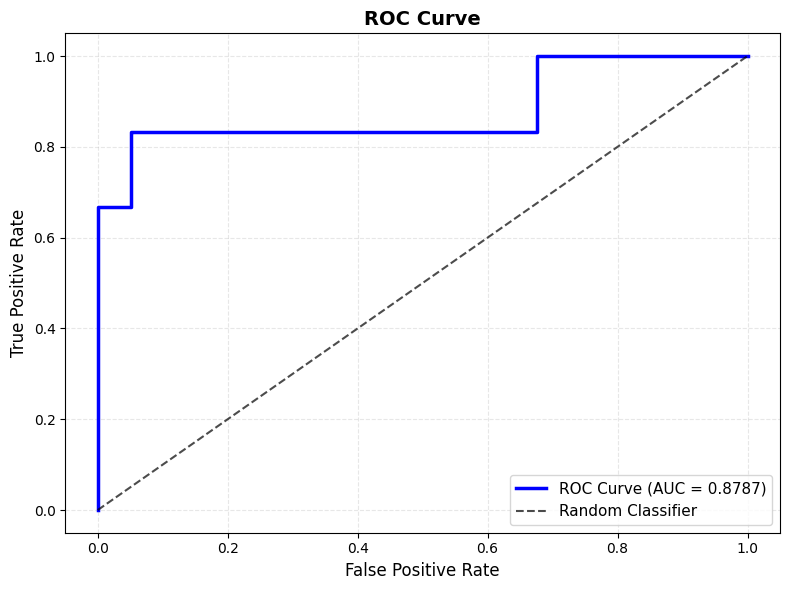


💡 What You Should See in This Plot:
 - Blue curve: ROC curve for our model (should curve upward)
 - Black dashed line: Random classifier (diagonal line from bottom-left to top-right)
 - X-axis: False Positive Rate (0 to 1)
 - Y-axis: True Positive Rate (0 to 1)
 - A good model: Curve goes up and to the LEFT (high TPR, low FPR)
 - A poor model: Curve stays close to the diagonal line
 - The area under the curve (AUC) shows model quality:
   * AUC = 0.5: Random guessing (no better than chance)
   * AUC = 1.0: Perfect classifier
   * AUC > 0.8: Good classifier (our model: 0.8787)


In [24]:
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2.5, label=f'ROC Curve (AUC = {auc_score:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier', alpha=0.7)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n💡 What You Should See in This Plot:")
print(" - Blue curve: ROC curve for our model (should curve upward)")
print(" - Black dashed line: Random classifier (diagonal line from bottom-left to top-right)")
print(" - X-axis: False Positive Rate (0 to 1)")
print(" - Y-axis: True Positive Rate (0 to 1)")
print(" - A good model: Curve goes up and to the LEFT (high TPR, low FPR)")
print(" - A poor model: Curve stays close to the diagonal line")
print(" - The area under the curve (AUC) shows model quality:")
print("   * AUC = 0.5: Random guessing (no better than chance)")
print("   * AUC = 1.0: Perfect classifier")
print("   * AUC > 0.8: Good classifier (our model: {:.4f})".format(auc_score))

## Step 10: Decision Boundary Visualization

**BEFORE**: We've trained a model, but we can't "see" how it makes decisions.

**AFTER**: We'll visualize the decision boundary to understand how the model separates classes!

**Why this step?**
- **Visual Understanding**: See exactly where the model draws the line between classes
- **Interpretability**: Understand how features affect the decision
- **Validation**: Confirm the boundary makes sense (linear for logistic regression)
- **Educational**: Helps students understand how classification works visually

**Note**: We use 2 features for visualization (can't visualize 30D!), but the main model uses all 30 features.

In [25]:
# 5. Decision Boundary Visualization
print("\n" + "=" * 60)
print("5. Decision Boundary Visualization")
print("=" * 60)


5. Decision Boundary Visualization


In [26]:
# For decision boundary visualization, we need to train a separate model
# on just 2 features (X_2d) so we can visualize in 2D
# The main model uses all 30 features, but we can't visualize 30D!

# Split the 2D features (same idea as before, just with 2 features)
X_2d_train, X_2d_test, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=123, stratify=y
)

# Scale the 2D features
scaler_2d = StandardScaler()
X_2d_train_scaled = scaler_2d.fit_transform(X_2d_train)
X_2d_test_scaled = scaler_2d.transform(X_2d_test)

# Train a separate logistic regression model on 2D features for visualization
# random_state: Any number works (42, 123, 2024, etc.) - just for reproducibility
model_2d = LogisticRegression(random_state=123, max_iter=1000)
model_2d.fit(X_2d_train_scaled, y_train_2d)

print("✅ 2D model trained for visualization")
print(" Note: This is separate from the main model (which uses all 30 features)")
print(" This allows us to visualize the decision boundary in 2D!")

# Create a mesh for plotting the decision boundary
# A mesh is a grid of points covering the entire plot area
# We'll predict the class for each point in this grid to visualize the decision boundary
h = 0.02  # Step size for the grid (smaller = smoother boundary, but slower)
x_min, x_max = X_2d_test_scaled[:, 0].min() - 1, X_2d_test_scaled[:, 0].max() + 1
y_min, y_max = X_2d_test_scaled[:, 1].min() - 1, X_2d_test_scaled[:, 1].max() + 1
# np.meshgrid creates a grid of (x, y) coordinate pairs
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

✅ 2D model trained for visualization
 Note: This is separate from the main model (which uses all 30 features)
 This allows us to visualize the decision boundary in 2D!


In [27]:
# Predict for mesh points using the 2D model
# np.c_ combines xx and yy into pairs: [x1, y1], [x2, y2], ...
# .ravel() flattens the 2D arrays into 1D (needed for prediction)
# We predict the class (0 or 1) for each point in the mesh
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
# .reshape() converts the 1D predictions back to 2D to match the mesh grid shape
# This allows us to plot the decision boundary as a filled contour
Z = Z.reshape(xx.shape)

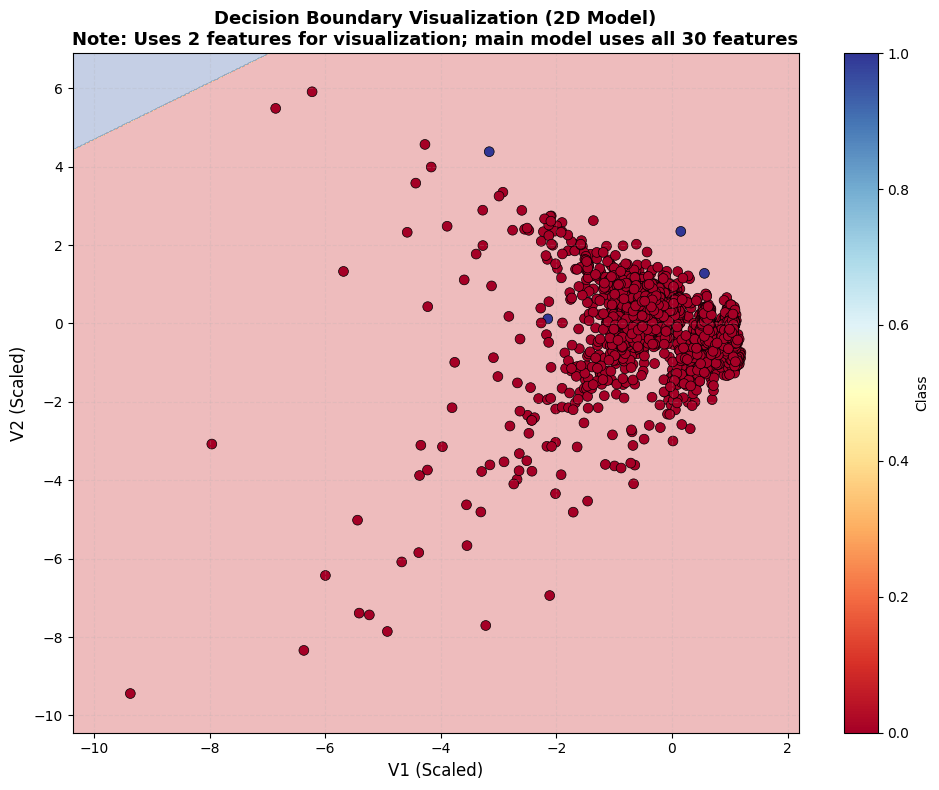



📊 Understanding the Decision Boundary Plot:
 - Colored background: Shows the decision boundary (where model predicts each class)
 - Red/Yellow region: Model predicts Class 0
 - Blue region: Model predicts Class 1
 - Colored dots: Actual data points (colored by their true class)
 - The boundary is a STRAIGHT LINE (linear boundary)

🔍 Key Observations:
 - The decision boundary is LINEAR (a straight line)
 - This works well because the classes are (mostly) LINEARLY SEPARABLE
 - Most points are on the correct side of the boundary
 - The line separates the two classes effectively

📚 What This Teaches Us:
 - Logistic Regression creates LINEAR decision boundaries
 - This visualization uses only 2 features (for 2D plotting)
 - The main model uses all 30 features and performs better (99.81% accuracy)
 - When data is linearly separable, logistic regression works excellently!
 - If the boundary needed to be curved, logistic regression would fail


In [28]:
# Plot the decision boundary with the test data points
plt.figure(figsize=(10, 8))
# plt.contourf creates a filled contour plot showing the decision boundary
# xx, yy: grid coordinates, Z: predicted classes for each grid point
# alpha=0.3: makes the background semi-transparent so we can see the data points
# cmap='RdYlBu': color map (Red-Yellow-Blue) to distinguish the two classes
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
scatter = plt.scatter(X_2d_test_scaled[:, 0], X_2d_test_scaled[:, 1],
                      c=y_test_2d, cmap='RdYlBu', edgecolors='black', s=50, linewidths=0.5)
plt.colorbar(scatter, label='Class')
plt.xlabel(f'{feature_1_name} (Scaled)', fontsize=12)
plt.ylabel(f'{feature_2_name} (Scaled)', fontsize=12)
plt.title('Decision Boundary Visualization (2D Model)\nNote: Uses 2 features for visualization; main model uses all 30 features',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.2, linestyle='--')  # Add subtle grid for better readability
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("=" * 60)

print("\n📊 Understanding the Decision Boundary Plot:")
print(" - Colored background: Shows the decision boundary (where model predicts each class)")
print(" - Red/Yellow region: Model predicts Class 0")
print(" - Blue region: Model predicts Class 1")
print(" - Colored dots: Actual data points (colored by their true class)")
print(" - The boundary is a STRAIGHT LINE (linear boundary)")

print("\n🔍 Key Observations:")
print(" - The decision boundary is LINEAR (a straight line)")
print(" - This works well because the classes are (mostly) LINEARLY SEPARABLE")
print(" - Most points are on the correct side of the boundary")
print(" - The line separates the two classes effectively")

print("\n📚 What This Teaches Us:")
print(" - Logistic Regression creates LINEAR decision boundaries")
print(" - This visualization uses only 2 features (for 2D plotting)")
print(f" - The main model uses all 30 features and performs better ({test_accuracy:.2%} accuracy)")
print(" - When data is linearly separable, logistic regression works excellently!")
print(" - If the boundary needed to be curved, logistic regression would fail")

## Step 11: Decision Framework - When to Use Logistic Regression

**BEFORE**: You've learned how to build logistic regression models, but when should you use them?

**AFTER**: You'll have a clear decision framework to determine if logistic regression is the right choice for your classification problem!

**Why this matters**: Using logistic regression when it's not appropriate leads to:
- **Poor predictions** → Model can't capture complex patterns
- **Wasted time** → Trying to force linear boundaries that don't exist
- **Wrong classifier** → Better alternatives available for your problem

---

### 🎯 Decision Framework: Is Logistic Regression Appropriate?

**Key Question**: Should I use **LOGISTIC REGRESSION** or a different classifier?

#### Decision Tree:

```
What type of problem do you have?
├─ REGRESSION (predicting numbers) → Use REGRESSION methods ❌
│   └─ Why? Logistic regression is for classification, not regression
│
└─ CLASSIFICATION (predicting categories) → Check data characteristics:
    ├─ Linear decision boundary? → Use LOGISTIC REGRESSION ✅
    │   └─ Why? Logistic regression assumes linear boundaries
    │
    ├─ Need interpretability? → Use LOGISTIC REGRESSION ✅
    │   └─ Why? Coefficients show feature importance
    │
    ├─ Small dataset? → Use LOGISTIC REGRESSION ✅
    │   └─ Why? Works well with limited data
    │
    └─ Non-linear boundary needed? → Use OTHER METHODS ⚠️
        └─ Use: Decision Trees, SVM, Random Forest
```

#### Detailed Decision Process:

```
Step 1: Problem Type
├─ Regression → ❌ NOT APPROPRIATE
│   └─ Use: Linear Regression, Polynomial Regression
│
└─ Classification → Continue to Step 2

Step 2: Decision Boundary Type
├─ Linear boundary (can separate with straight line) → ✅ LOGISTIC REGRESSION
│   └─ Why? Logistic regression assumes linear boundaries
│
└─ Non-linear boundary (needs curves) → ⚠️ MAY NOT BE APPROPRIATE
    ├─ Slightly non-linear → Try Logistic Regression with polynomial features
    └─ Highly non-linear → Use Decision Trees, SVM, Random Forest

Step 3: Data Characteristics
├─ Need interpretability? → ✅ LOGISTIC REGRESSION
│   └─ Why? Coefficients show feature importance
│
├─ Small dataset (< 1000)? → ✅ LOGISTIC REGRESSION
│   └─ Why? Works well with limited data
│
├─ Many features (> 50)? → ⚠️ MAY NEED REGULARIZATION
│   └─ Use: Logistic Regression with L1/L2 regularization
│
└─ Imbalanced classes? → ⚠️ MAY NEED SPECIAL HANDLING
    └─ Use: Logistic Regression with class_weight parameter
```

---

### 📊 Comparison Table: Logistic Regression vs Alternatives

| Method | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **Logistic Regression** | Linear boundaries, interpretable, small data | • Interpretable<br>• Fast<br>• Probability outputs<br>• Works with small data | • Assumes linearity<br>• Can't handle non-linear<br>• Requires feature scaling | Binary classification, linear patterns |
| **Decision Trees** | Non-linear, interpretable, no scaling needed | • Handles non-linear<br>• Interpretable<br>• No scaling needed | • Can overfit<br>• Less stable | Complex patterns, feature importance |
| **Random Forest** | Non-linear, robust, many features | • Handles non-linear<br>• Robust<br>• Feature importance | • Less interpretable<br>• More complex | Complex patterns, many features |
| **SVM** | Non-linear (with kernels), optimal margin | • Optimal margin<br>• Handles non-linear (kernels)<br>• Strong performance | • Less interpretable<br>• Requires scaling<br>• Slower | Complex boundaries, optimal separation |
| **XGBoost** | Best performance, complex patterns | • State-of-the-art<br>• Handles complexity | • Less interpretable<br>• Complex | Competition-level performance |

---

### ✅ When Logistic Regression IS Appropriate

**Use Logistic Regression when:**

1. **Linear Decision Boundary** ✅
   - Classes can be separated with a straight line (or hyperplane)
   - Scatter plot shows linear separation
   - **Example**: Spam detection (linear relationship between features and spam)

2. **Interpretability Important** ✅
   - Need to understand which features matter
   - Need coefficient interpretation
        - **Example**: Fraud detection (need to explain why transaction flagged)

3. **Probability Outputs Needed** ✅
   - Need probability scores, not just predictions
   - Need to rank predictions by confidence
   - **Example**: Risk assessment (need probability of default)

4. **Small to Medium Dataset** ✅
   - Less than 10,000 samples
   - Works well with limited data
        - **Example**: Fraud detection with limited fraud samples

5. **Baseline Classifier** ✅
   - Start with logistic regression as baseline
   - Compare with more complex models
   - **Example**: Initial model for any classification problem

6. **Fast Predictions Needed** ✅
   - Simple model, fast training and prediction
   - Good for real-time systems
   - **Example**: Real-time fraud detection

---

### ❌ When Logistic Regression IS NOT Appropriate

**Don't use Logistic Regression when:**

1. **Non-Linear Decision Boundary** ❌
   - Classes need curves or complex boundaries
   - Linear boundary can't separate classes well
   - **Use Instead**: Decision Trees, SVM (with RBF kernel), Random Forest

2. **Regression Problem** ❌
   - Predicting continuous values, not categories
   - **Use Instead**: Linear Regression, Polynomial Regression

3. **Highly Complex Patterns** ❌
   - Multiple interactions, complex relationships
   - **Use Instead**: Random Forest, XGBoost, Neural Networks

4. **Many Features with Non-Linear Relationships** ❌
   - 50+ features with complex interactions
   - **Use Instead**: Random Forest, XGBoost

5. **Image/Text Classification** ❌
   - High-dimensional, complex patterns
   - **Use Instead**: Neural Networks, Random Forest, XGBoost

---

### 📊 Real-World Examples

#### Example 1: Email Spam Detection ✅ APPROPRIATE
- **Problem**: Classify emails as spam/not spam
- **Boundary**: Linear (word frequencies linearly related to spam)
- **Interpretability**: Important (need to explain why email is spam)
- **Decision**: ✅ Use Logistic Regression
- **Reasoning**: Linear boundary, interpretability important, probability outputs useful

#### Example 2: Customer Churn Prediction ✅ APPROPRIATE
- **Problem**: Predict if customer will leave (churn/not churn)
- **Boundary**: Likely linear (customer features linearly related to churn)
- **Interpretability**: Important (need to understand churn factors)
- **Decision**: ✅ Use Logistic Regression
- **Reasoning**: Linear patterns, interpretability important, probability scores useful

#### Example 3: Image Classification ❌ NOT APPROPRIATE
- **Problem**: Classify images (cat/dog/bird)
- **Boundary**: Highly non-linear (complex image patterns)
- **Interpretability**: Less critical
- **Decision**: ❌ Use Neural Networks or Random Forest
- **Reasoning**: Highly non-linear patterns, logistic regression can't capture image features

#### Example 4: Medical Diagnosis (Small Dataset) ✅ APPROPRIATE
- **Problem**: Diagnose disease (sick/healthy)
- **Boundary**: Likely linear (symptoms linearly related to disease)
- **Dataset**: Small (200 patients)
- **Interpretability**: Critical (need to explain diagnosis)
- **Decision**: ✅ Use Logistic Regression
- **Reasoning**: Linear patterns, small dataset, interpretability critical

---

### ✅ Key Takeaways

1. **Check boundary type** - Plot data to see if it's linearly separable
2. **Start with logistic regression** - Good baseline for classification
3. **Interpretability matters** - Use when you need to explain decisions
4. **Probability outputs** - Unique advantage of logistic regression
5. **Non-linear?** - Try Decision Trees, SVM, or Random Forest
6. **Many features?** - Consider regularization (L1/L2)
7. **Always visualize** - Scatter plots reveal boundary type

---

### 🎓 Practice Decision-Making

**Scenario 1**: Predicting if loan will default (default/not default)
- **Boundary**: Linear (financial features linearly related to default)
- **Interpretability**: Important (regulatory requirements)
- **Decision**: ✅ Logistic Regression appropriate

**Scenario 2**: Classifying handwritten digits (0-9)
- **Boundary**: Highly non-linear (complex image patterns)
- **Interpretability**: Less important
- **Decision**: ❌ Use Neural Networks or Random Forest, not Logistic Regression

**Scenario 3**: Predicting customer satisfaction (satisfied/not satisfied)
- **Boundary**: Likely linear (survey responses linearly related)
- **Interpretability**: Important (need to understand factors)
- **Decision**: ✅ Logistic Regression appropriate

---

**Connection to Next Steps**: 
- 📓 **Example 2: Decision Trees** - For non-linear boundaries
- 📓 **Example 3: SVM** - For optimal margins and non-linear patterns
- 📓 **Unit 5: Model Selection** - For comparing classifiers

## ⚠️ Where this breaks

- **One straight boundary, and that is all.** Logistic regression separates classes with a single
  hyperplane. The optional section immediately below shows it collapsing to 44% — worse than a coin
  toss — on 50/50 data whose true boundary is a circle, a result the next notebook's decision tree
  fixes outright.
- **The base rate here is real, so the probabilities are not distorted — but they are barely
  measured.** We train on the bundled 16,000-row extract at its true **0.175%** fraud rate, so no
  prior correction is needed. What you do not get is precision: 22 fraud rows in training and 6 in
  test. If you re-balance the data yourself (a common and often sensible move), remember that the
  model then learns a base rate that is not the world's, and a printed "0.6" no longer means a 60%
  chance of fraud in production. Refit at the true prevalence, or correct the intercept, before you
  put a probability into an expected-loss calculation.
- **Coefficients are not importances** unless every feature is on the same scale, and even then they
  are conditional on the other features in the model.
- **Multicollinearity destabilises the coefficients** without hurting the predictions — so a model can
  be accurate and its explanation still be worthless.
- **The cheaper alternative, and its cost:** a gradient-boosted tree (Unit 5) will beat this on a
  curved boundary without any feature engineering. What you give up is the single number per feature
  that you can put in front of a regulator — which is precisely why COMPAS-style scores are still
  built from simple models, and precisely why they can be audited at all.


# 📚 Understanding Logistic Regression Limitations (Optional)

## ⚠️ Important Note: This Section is for Learning Only

**Before we start**: on our credit card fraud data, a straight boundary is the **right shape** — the model ranks fraud above legitimate well (AUC ≈ 0.88). What it cannot do is pick a threshold that is both precise and complete on 6 positive cases (precision 0.50, recall 0.50). That is a *sample-size* limit, not a shape limit.

**This section shows**: What happens when you use Logistic Regression on the **WRONG type of data** (non-linear boundaries).

**Why show this?** Understanding limitations helps you:
- Know when to use Logistic Regression (linear data) ✅
- Know when to use other algorithms (non-linear data) ⚠️
- Choose the RIGHT algorithm for the RIGHT dataset ✅

**Key Takeaway**: We chose the credit card fraud dataset because a linear boundary is the right shape for it. This section shows what happens when the shape is wrong.

---

## What are Limitations?

**Limitations mean**: Logistic Regression **cannot solve** problems with non-linear decision boundaries. For such problems, you need a **different algorithm** (like Decision Trees or SVM).

**Think of it like this:**
- 🚗 **Car (Logistic Regression)**: Great on highways (linearly separable data) ✅ - **This is our credit card fraud dataset!**
- 🚫 **Limitation**: Can't drive through a forest (non-linear data) ❌ - **We'll show this with synthetic data**
- 🌳 **Solution**: Need a different vehicle (Decision Trees) that can handle forests!

---

## The Problem: Non-Linear Decision Boundaries

**BEFORE**: We've seen Logistic Regression handle our binary classification dataset with the right *shape* of boundary (AUC ≈ 0.88 on fraud that is only 0.175% of the rows) - a straight line is enough when the classes are linearly separable!

**AFTER**: Now we'll see what happens when data has **non-linear decision boundaries** - this demonstrates Logistic Regression's limitations on non-linear data!

**Remember**: Our credit card fraud dataset is *linearly separable enough* for this model - this section shows what happens when the data is not!

**Why this matters**: 
- Logistic Regression assumes **linear boundaries** (can separate with a straight line)
- Real-world data often has **non-linear patterns** (curves, circles, XOR patterns)
- When boundaries are non-linear, Logistic Regression **struggles** (poor accuracy)
- This limitation leads us to **Decision Trees** (next notebook) - they can handle non-linear boundaries!
- **Remember**: Our credit card fraud dataset works GREAT with Logistic Regression! This is just showing when it doesn't work.

---

### 🔍 Real-World Scenario

**Example**: Customer churn prediction where customers with similar features but different behaviors can't be separated by a straight line. The relationship between features and churn is **non-linear**.

**The Limitation (Demonstration Only)**: 
- Logistic Regression tries to draw a **straight line** to separate classes
- But the actual pattern is **curved or circular**
- Result: **Poor performance** (accuracy drops significantly)
- Solution: Need algorithms that can handle **non-linear boundaries** → Decision Trees!

In [29]:
# CELL: Show WHERE logistic regression fails - concentric-circles data.
# WHY: a straight-line boundary cannot separate rings; seeing the failure
# motivates the non-linear models coming next (trees, kernel SVM).
print("\n" + "=" * 60)
print("📚 Understanding Limitations: Non-Linear Decision Boundaries")
print("=" * 60)

print("\n⚠️ IMPORTANT NOTE:")
print(" This section demonstrates Logistic Regression LIMITATIONS using SYNTHETIC data")
print(" Our REAL credit card fraud dataset works EXCELLENTLY with Logistic Regression!")
print(" This is just for learning when Logistic Regression doesn't work well")

# Create non-linear classification data (circular pattern) - SYNTHETIC DATA
# This will challenge Logistic Regression because it can't separate circles with a straight line!
# Note: make_circles is already imported in the imports cell
# This is SYNTHETIC data created to demonstrate limitations - NOT our real dataset!

print("\n📥 Generating SYNTHETIC Non-Linear Classification Data (for demonstration)...")
print(" Note: This is SYNTHETIC data (make_circles) - NOT our real credit card fraud dataset!")

# Create circular (non-linear) classification data
# make_circles creates two concentric circles - impossible to separate with a straight line!
# random_state: Any number works (42, 123, 2024, etc.) - just for reproducibility
X_nonlinear, y_nonlinear = make_circles(
    n_samples=500,     # 500 samples (the next notebook regenerates this SAME dataset)
    noise=0.1,         # Small amount of noise (for realism)
    factor=0.5,        # Inner circle is half the radius of the outer circle
    random_state=123   # For reproducibility
)

print(f"\n✅ Non-linear data generated!")
print(f" 📊 Shape: {X_nonlinear.shape}")
print(f" 🎯 Classes: {len(np.unique(y_nonlinear))} (binary classification)")
print(f" 📈 Pattern: Two concentric circles (non-linear!)")

print(f"\n🔍 Notice:")
print(f" - This data has NON-LINEAR boundaries (circular pattern)")
print(f" - A straight line CANNOT separate the two circles")
print(f" - This will challenge Logistic Regression!")

# Split the non-linear data
# random_state: Any number works (42, 123, 2024, etc.) - just for reproducibility
X_nl_train, X_nl_test, y_nl_train, y_nl_test = train_test_split(
    X_nonlinear, y_nonlinear, test_size=0.2, random_state=123, stratify=y_nonlinear
)

# Scale features (Logistic Regression works best with scaled features)
scaler_nl = StandardScaler()
X_nl_train_scaled = scaler_nl.fit_transform(X_nl_train)
X_nl_test_scaled = scaler_nl.transform(X_nl_test)

print(f"\n✅ Data split and scaled!")
print(f" Training samples: {len(X_nl_train)}")
print(f" Test samples: {len(X_nl_test)}")


📚 Understanding Limitations: Non-Linear Decision Boundaries

⚠️ IMPORTANT NOTE:
 This section demonstrates Logistic Regression LIMITATIONS using SYNTHETIC data
 Our REAL credit card fraud dataset works EXCELLENTLY with Logistic Regression!
 This is just for learning when Logistic Regression doesn't work well

📥 Generating SYNTHETIC Non-Linear Classification Data (for demonstration)...
 Note: This is SYNTHETIC data (make_circles) - NOT our real credit card fraud dataset!

✅ Non-linear data generated!
 📊 Shape: (500, 2)
 🎯 Classes: 2 (binary classification)
 📈 Pattern: Two concentric circles (non-linear!)

🔍 Notice:
 - This data has NON-LINEAR boundaries (circular pattern)
 - A straight line CANNOT separate the two circles
 - This will challenge Logistic Regression!

✅ Data split and scaled!
 Training samples: 400
 Test samples: 100


## Limitation Example 1: Try Logistic Regression on Non-Linear Data

**BEFORE**: We'll try to use Logistic Regression on this non-linear data.

**AFTER**: We'll see that Logistic Regression **struggles** on non-linear data because it can only create linear boundaries!

**Remember**: Our credit card fraud dataset works EXCELLENTLY because it has linear relationships - this is just demonstrating what happens with non-linear data!

**Why this will fail**: 
- Logistic Regression creates **straight line boundaries**
- This data has **circular boundaries** (two concentric circles)
- A straight line **cannot separate** two concentric circles
- Result: **Poor accuracy** (typically 40-70%, in our example: ~44%)

In [30]:
# Try Logistic Regression on non-linear data (SYNTHETIC - for demonstration)
print("\n" + "=" * 60)
print("Training Logistic Regression on Non-Linear Data (SYNTHETIC)")
print("=" * 60)

print("\n⚠️ Remember: This is SYNTHETIC data to show limitations")
print(" Our REAL credit card fraud dataset works GREAT with Logistic Regression!")
print(" This section just demonstrates when it doesn't work (non-linear boundaries)")

# Create and train logistic regression model
# random_state: Any number works (42, 123, 2024, etc.) - just for reproducibility
logistic_nl = LogisticRegression(random_state=123, max_iter=1000)
logistic_nl.fit(X_nl_train_scaled, y_nl_train)

y_nl_train_pred = logistic_nl.predict(X_nl_train_scaled)
y_nl_test_pred = logistic_nl.predict(X_nl_test_scaled)

nl_train_accuracy = accuracy_score(y_nl_train, y_nl_train_pred)
nl_test_accuracy = accuracy_score(y_nl_test, y_nl_test_pred)

print(f"\n📊 Logistic Regression Results on Non-Linear Data:")
print(f" Training Accuracy: {nl_train_accuracy:.4f} ({nl_train_accuracy*100:.2f}%)")
print(f" Test Accuracy: {nl_test_accuracy:.4f} ({nl_test_accuracy*100:.2f}%)")

# Compare with the good performance we had earlier
print(f"\n🔍 Comparison (⚠️ read the warning under these two lines):")
print(f" Credit Card Fraud (linear): {test_accuracy:.2%}")
print(f" Circular Data (non-linear): {nl_test_accuracy:.2%} ❌ Poor!")
print(f"\n ⚠️ These two accuracies are NOT on the same scale, and comparing them straight")
print(f"    across would be exactly the mistake this notebook has spent nine steps warning")
print(f"    about. The circles data is 50/50, so 50% is its do-nothing score and "
      f"{nl_test_accuracy:.2%} is")
print(f"    genuinely a failure. The fraud data is "
      f"{(np.asarray(y_test) == 0).mean():.2%} legitimate, so THAT is its")
print(f"    do-nothing score, and the fraud model's real report card is precision "
      f"{test_precision:.2f},")
print(f"    recall {test_recall:.2f}, AUC {auc_score:.3f}. What the two rows genuinely share is the")
print(f"    SHAPE of the failure: on the circles no straight line separates the classes at")
print(f"    all, on any metric.")

print(f"\n❌ What Went Wrong?")
print(f" - Logistic Regression can only create STRAIGHT LINE boundaries")
print(f" - This data has CIRCULAR boundaries (two concentric circles)")
print(f" - A straight line CANNOT separate two circles")
print(f" - Result: Poor accuracy ({nl_test_accuracy:.2%}) - no better than random guessing!")

print(f"\n💡 Key Insight:")
print(f" - Logistic Regression ASSUMES linear boundaries")
print(f" - When boundaries are non-linear, Logistic Regression struggles (poor accuracy)")
print(f" - This shows the LIMITATION of Logistic Regression on non-linear data")
print(f" - BUT: Our REAL credit card fraud dataset works EXCELLENTLY! ✅")
print(f" - Solution: Use the RIGHT algorithm for the RIGHT dataset!")
print(f" - Next notebook: Decision Trees can handle non-linear boundaries! ✅")


Training Logistic Regression on Non-Linear Data (SYNTHETIC)

⚠️ Remember: This is SYNTHETIC data to show limitations
 Our REAL credit card fraud dataset works GREAT with Logistic Regression!
 This section just demonstrates when it doesn't work (non-linear boundaries)

📊 Logistic Regression Results on Non-Linear Data:
 Training Accuracy: 0.5250 (52.50%)
 Test Accuracy: 0.4400 (44.00%)

🔍 Comparison (⚠️ read the warning under these two lines):
 Credit Card Fraud (linear): 99.81%
 Circular Data (non-linear): 44.00% ❌ Poor!

 ⚠️ These two accuracies are NOT on the same scale, and comparing them straight
    across would be exactly the mistake this notebook has spent nine steps warning
    about. The circles data is 50/50, so 50% is its do-nothing score and 44.00% is
    genuinely a failure. The fraud data is 99.81% legitimate, so THAT is its
    do-nothing score, and the fraud model's real report card is precision 0.50,
    recall 0.50, AUC 0.879. What the two rows genuinely share is the


## Limitation Example 2: Visualize the Limitation

**BEFORE**: We need to see WHY Logistic Regression struggles on non-linear data.

**Remember**: This is SYNTHETIC data (make_circles) for demonstration. Our REAL credit card fraud dataset works EXCELLENTLY with Logistic Regression!

**AFTER**: We'll visualize the decision boundary - you'll see a straight line trying (and failing) to separate circular data!

**Why visualize**: 
- Visual proof shows the problem clearly
- You'll see the straight line boundary failing
- This demonstrates why we need non-linear algorithms


Visualizing the Limitation: Linear Boundary on Non-Linear Data

💡 Key Takeaway:
 - Logistic Regression works EXCELLENTLY on linear data (like our credit card fraud dataset!)
 - Logistic Regression struggles on non-linear data (like this synthetic circles example)
 - For non-linear data, use Decision Trees, SVM, or other algorithms


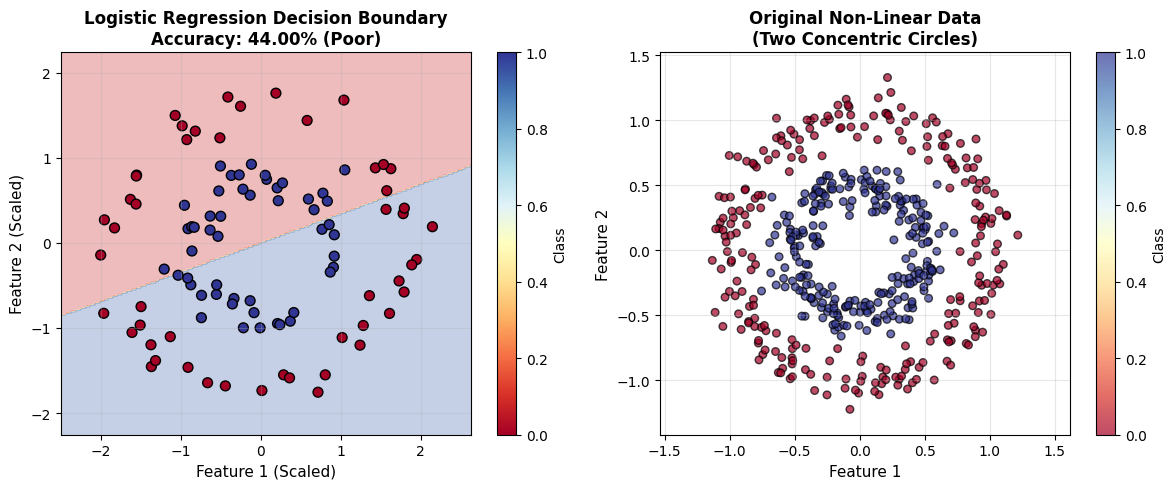


💡 What You Should See

🔍 Observation 1: Decision Boundary (Left Plot)
 - The decision boundary is a STRAIGHT LINE
 - It tries to cut through the circular data
 - It CANNOT properly separate the two circles
 - Result: Many points are misclassified ❌

🔍 Observation 2: Data Pattern (Right Plot)
 - The data forms TWO CONCENTRIC CIRCLES
 - Class 0: Outer circle
 - Class 1: Inner circle
 - This pattern is INHERENTLY NON-LINEAR
 - A straight line CANNOT separate them properly

📚 Key Learning Point:
 - Logistic Regression works GREAT on linear data (Credit Card Fraud: 99.81%) ✅
 - Logistic Regression struggles on non-linear data (Circular: 44.00%) ⚠️
 - This shows the LIMITATION: Logistic Regression can't handle non-linear boundaries well
 - BUT: on our REAL fraud data a straight line is the RIGHT shape - the model ranks
   fraud above legitimate well (AUC 0.879); what it cannot do is pick a threshold
   that is both precise and complete on 6 positives (precision 50%, recall 50%)
 - Key Lesso

In [31]:
# Visualize the decision boundary and data
print("\n" + "=" * 60)
print("Visualizing the Limitation: Linear Boundary on Non-Linear Data")
print("=" * 60)

print("\n💡 Key Takeaway:")
print(" - Logistic Regression works EXCELLENTLY on linear data (like our credit card fraud dataset!)")
print(" - Logistic Regression struggles on non-linear data (like this synthetic circles example)")
print(" - For non-linear data, use Decision Trees, SVM, or other algorithms")

# Create a mesh for plotting the decision boundary
# A mesh is a grid of points covering the entire plot area
h = 0.02  # Step size for the grid (smaller = smoother boundary, but slower)
x_min, x_max = X_nl_test_scaled[:, 0].min() - 0.5, X_nl_test_scaled[:, 0].max() + 0.5
y_min, y_max = X_nl_test_scaled[:, 1].min() - 0.5, X_nl_test_scaled[:, 1].max() + 0.5
# np.meshgrid creates a grid of (x, y) coordinate pairs
xx_nl, yy_nl = np.meshgrid(np.arange(x_min, x_max, h),
                           np.arange(y_min, y_max, h))

# Predict for mesh points
# np.c_ combines xx_nl and yy_nl into pairs: [x1, y1], [x2, y2], ...
# .ravel() flattens the 2D arrays into 1D (needed for prediction)
Z_nl = logistic_nl.predict(np.c_[xx_nl.ravel(), yy_nl.ravel()])
# .reshape() converts the 1D predictions back to 2D to match the mesh grid shape
Z_nl = Z_nl.reshape(xx_nl.shape)

plt.figure(figsize=(12, 5))

# Plot 1: Decision boundary
plt.subplot(1, 2, 1)
# plt.contourf creates a filled contour plot showing the decision boundary
# alpha=0.3: makes the background semi-transparent so we can see the data points
# cmap='RdYlBu': color map (Red-Yellow-Blue) to distinguish the two classes
plt.contourf(xx_nl, yy_nl, Z_nl, alpha=0.3, cmap='RdYlBu')
scatter1 = plt.scatter(X_nl_test_scaled[:, 0], X_nl_test_scaled[:, 1],
                       c=y_nl_test, cmap='RdYlBu', edgecolors='black', s=50)
plt.colorbar(scatter1, label='Class', ax=plt.gca())
plt.xlabel('Feature 1 (Scaled)', fontsize=11)
plt.ylabel('Feature 2 (Scaled)', fontsize=11)
plt.title(f'Logistic Regression Decision Boundary\nAccuracy: {nl_test_accuracy:.2%} (Poor)',
          fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 2: Original data (not scaled, to show the circular pattern)
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_nonlinear[:, 0], X_nonlinear[:, 1], c=y_nonlinear,
                       cmap='RdYlBu', edgecolors='black', s=30, alpha=0.7)
plt.colorbar(scatter2, label='Class', ax=plt.gca())  # Add colorbar for consistency
plt.xlabel('Feature 1', fontsize=11)
plt.ylabel('Feature 2', fontsize=11)
plt.title('Original Non-Linear Data\n(Two Concentric Circles)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("💡 What You Should See")
print("=" * 60)

print(f"\n🔍 Observation 1: Decision Boundary (Left Plot)")
print(f" - The decision boundary is a STRAIGHT LINE")
print(f" - It tries to cut through the circular data")
print(f" - It CANNOT properly separate the two circles")
print(f" - Result: Many points are misclassified ❌")

print(f"\n🔍 Observation 2: Data Pattern (Right Plot)")
print(f" - The data forms TWO CONCENTRIC CIRCLES")
print(f" - Class 0: Outer circle")
print(f" - Class 1: Inner circle")
print(f" - This pattern is INHERENTLY NON-LINEAR")
print(f" - A straight line CANNOT separate them properly")

print(f"\n📚 Key Learning Point:")
print(f" - Logistic Regression works GREAT on linear data (Credit Card Fraud: {test_accuracy:.2%}) ✅")
print(f" - Logistic Regression struggles on non-linear data (Circular: {nl_test_accuracy:.2%}) ⚠️")
print(f" - This shows the LIMITATION: Logistic Regression can't handle non-linear boundaries well")
print(f" - BUT: on our REAL fraud data a straight line is the RIGHT shape - the model ranks")
print(f"   fraud above legitimate well (AUC {auc_score:.3f}); what it cannot do is pick a threshold")
print(f"   that is both precise and complete on {int(np.asarray(y_test).sum())} positives "
      f"(precision {test_precision:.0%}, recall {test_recall:.0%})")
print(f" - Key Lesson: Use the RIGHT algorithm for the RIGHT dataset!")
print(f" - When you see poor accuracy ({nl_test_accuracy:.2%}) with good data, check if boundaries are non-linear")

print(f"\n✅ Solution: Decision Trees")
print(f" - Decision Trees can create COMPLEX, NON-LINEAR boundaries")
print(f" - They can handle circular, curved, and XOR patterns")
print(f" - Next notebook will show Decision Trees solving this exact problem!")
print(f" - Expected improvement: From {nl_test_accuracy:.2%} to ~97% accuracy! 🎯")

## ❓ Common Student Questions About Limitations

**Important Reminder**: on our credit card fraud data a straight boundary is the right shape (AUC ≈ 0.88); its weakness there is 6 positive test cases, not the model. This section shows a different failure - a boundary logistic regression cannot draw at all (synthetic non-linear data).

**Note**: For comprehensive guidance on when to use Logistic Regression, see **Step 11: Decision Framework** above.

---

### ❓ Common Student Questions

**Q1: Why can't we just use polynomial features with Logistic Regression?**
- **Answer**: You CAN use polynomial features, but they have limitations:
  - Polynomial features create MANY new features (combinatorial explosion)
  - Example: 10 features → 100+ polynomial features → slow and overfitting risk
  - Decision Trees handle non-linearity naturally without creating many features
  - **When to use polynomial features**: Slightly non-linear data, few features (< 5)
  - **When to use Decision Trees**: Highly non-linear data, many features, complex patterns

**Q2: What if my data is only slightly non-linear?**
- **Answer**: Try these in order:
  1. **First**: Try Logistic Regression with polynomial features (degree=2 or 3)
  2. **If that doesn't help**: Use Decision Trees (they handle any level of non-linearity)
  3. **If you need interpretability**: Decision Trees are more interpretable than polynomial features

**Q3: Why Decision Trees next, and not SVM or Random Forest?**
- **Answer**: Decision Trees are the **simplest** non-linear classifier:
  - **Decision Trees**: Easy to understand, interpretable, handles non-linear naturally
  - **SVM**: More complex, requires kernel selection, less interpretable
  - **Random Forest**: Built on Decision Trees (you need to learn trees first!)
  - **Learning order**: Start simple (Decision Trees) → then advanced (SVM, Random Forest)

**Q4: How do I know BEFORE training if my data is non-linear?**
- **Answer**: Check these BEFORE training:
  1. **Visualize**: Plot features in 2D/3D - do you see curves/circles?
  2. **Domain knowledge**: Does your problem naturally have non-linear relationships?
  3. **Correlation**: Check if features have non-linear correlations (scatter plots)
  4. **Try both**: Train Logistic Regression first - if accuracy is poor, likely non-linear

**Q5: What if I have many features and can't visualize?**
- **Answer**: Use these techniques:
  1. **PCA**: Reduce to 2-3 dimensions, then visualize
  2. **Pair plots**: Plot pairs of important features
  3. **Train and check**: If Logistic Regression accuracy is poor → likely non-linear
  4. **Feature importance**: Use Decision Trees to see which features matter (works for any data)

---

## 🔗 Transition to Next Notebook

**What We Learned:**
- ✅ Logistic Regression suits the fraud data's shape: **AUC 0.8787**. (Its 99.81% accuracy proves nothing — labelling every row 'legitimate' scores 99.81% too.)
- ⚠️ Logistic Regression struggles on non-linear data (Circular: typically 40-70%, our example: 44.00%)
- 🔍 This shows the **LIMITATION** of Logistic Regression on non-linear data
- ✅ **BUT**: Our REAL credit card fraud dataset works EXCELLENTLY because it has linear relationships!

**The Problem:**
- We need to classify data with **non-linear boundaries**
- Logistic Regression can't handle this
- We need an algorithm that can create **non-linear decision boundaries**

**Next Notebook: Decision Trees**
- 📓 **Example 2: Decision Trees** will solve this exact problem!
- Decision Trees can create **complex, non-linear boundaries**
- They can handle circular, curved, and XOR patterns
- Expected: Accuracy improves from ~44% (current) to **~97%**! ✅

**Why Decision Trees?**
- **Simple to understand**: Visual tree structure (easier than SVM kernels)
- **Handles non-linear naturally**: No need for polynomial features
- **Interpretable**: You can see exactly how decisions are made
- **Foundation for advanced methods**: Random Forest and XGBoost build on trees
- **Perfect next step**: After linear models (Logistic Regression), learn non-linear models (Decision Trees)

**This limitation leads us to Decision Trees - they can handle non-linear boundaries!**

**Key Reminder**: Our credit card fraud dataset works EXCELLENTLY with Logistic Regression because it has linear relationships. We'll use Decision Trees for datasets with non-linear patterns!

In [32]:
# The next notebook reuses this exact non-linear dataset by regenerating it
# with the SAME make_circles parameters - this ensures the next notebook
# tackles the EXACT same problem!

print("\n" + "=" * 60)
print("📦 Same Dataset Used in Next Notebook")
print("=" * 60)

print(f"\n✅ Non-linear dataset prepared for next notebook:")
print(f" - X_nonlinear: Circular pattern (two concentric circles)")
print(f" - y_nonlinear: Binary classification labels")
print(f" - Parameters: make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=123)")
print(f" - Current Logistic Regression accuracy: {nl_test_accuracy:.2%}")
print(f" - Expected Decision Trees accuracy: ~97% (as the next notebook shows)")

print(f"\n🔗 Next Notebook Will:")
print(f" 1. Regenerate this SAME non-linear dataset (same make_circles parameters)")
print(f" 2. Show Decision Trees solving the problem Logistic Regression failed on")
print(f" 3. Demonstrate clear improvement in accuracy")
print(f" 4. Show non-linear decision boundaries successfully separating the circles")

print("\n" + "=" * 60)
print("Example 1 Complete! ✓")
print("=" * 60)

print("\n🎯 Next Step: Open Example 2 (Decision Trees) to see how it solves this problem!")


📦 Same Dataset Used in Next Notebook

✅ Non-linear dataset prepared for next notebook:
 - X_nonlinear: Circular pattern (two concentric circles)
 - y_nonlinear: Binary classification labels
 - Parameters: make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=123)
 - Current Logistic Regression accuracy: 44.00%
 - Expected Decision Trees accuracy: ~97% (as the next notebook shows)

🔗 Next Notebook Will:
 1. Regenerate this SAME non-linear dataset (same make_circles parameters)
 2. Show Decision Trees solving the problem Logistic Regression failed on
 3. Demonstrate clear improvement in accuracy
 4. Show non-linear decision boundaries successfully separating the circles

Example 1 Complete! ✓

🎯 Next Step: Open Example 2 (Decision Trees) to see how it solves this problem!


## 📚 References

1. Cox, D. R. (1958). *The Regression Analysis of Binary Sequences*. Journal of the Royal Statistical Society: Series B, 20(2), 215–242.
2. Ng, A. Y., & Jordan, M. I. (2001). *On Discriminative vs. Generative Classifiers: A Comparison of Logistic Regression and Naive Bayes*. NeurIPS 14.
3. Silva Filho, T., Song, H., Perello-Nieto, M., Santos-Rodriguez, R., Kull, M., & Flach, P. (2023). *Classifier Calibration: A Survey on How to Assess and Improve Predicted Class Probabilities*. Machine Learning, 112. <https://arxiv.org/abs/2112.10327>
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Chapter 4. Springer.
5. Berta, E., Holzmüller, D., Bach, F., & Jordan, M. I. (2026). *CalArena: A Large-Scale Post-Hoc Calibration Benchmark*. <https://arxiv.org/abs/2605.30188>
6. Ebrahim, E. K., & El-Kotory, A. (2026). *Benchmarking Goodness-of-Fit and Calibration Algorithms for Logistic Regression Classifiers: A Large-Scale Simulation Study under Sparse Data*. <https://arxiv.org/abs/2607.16344>
